## Import

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "mass_smaller_30"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


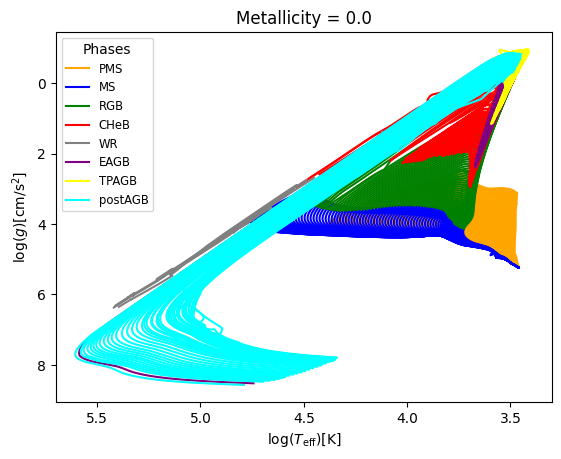

In [4]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

In [5]:
print_uniques("star_mass", iso_df)
# print_uniques_count("star_mass", iso_df)

star_mass : 1467117 unique values, range [0.0999979840073621, 298.5447575808816]


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
633331,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
633332,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
633333,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
633334,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


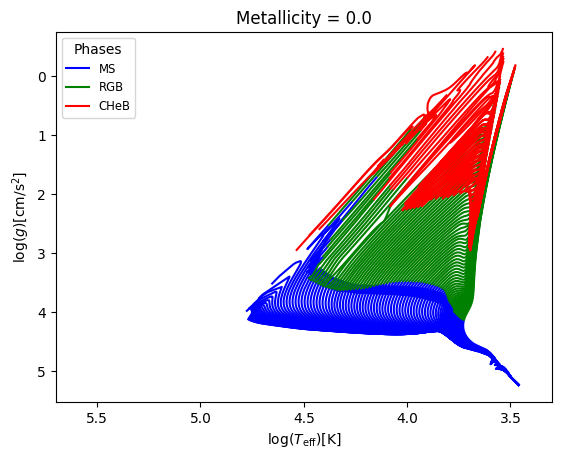

In [6]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [7]:
print_uniques("star_mass", phase_filtered_iso_df)
# print_uniques_count("star_mass", phase_filtered_iso_df)

star_mass : 633336 unique values, range [0.0999979840073621, 298.5447575808816]


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
576729,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
576730,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
576731,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
576732,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


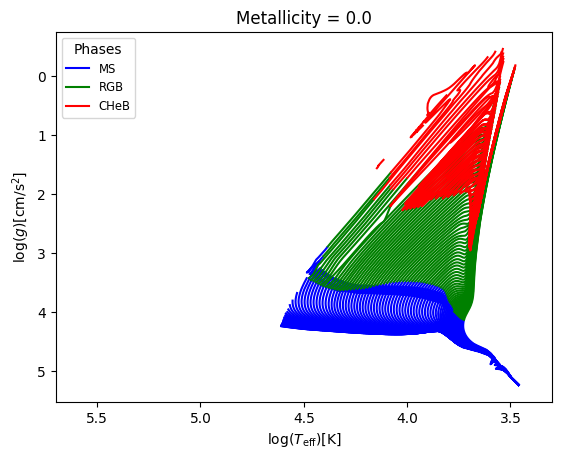

In [8]:
phase_mass_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], "star_mass" : ("<", 30)})
display(phase_mass_filtered_iso_df)
data_visualiser_phase_age_filtered = Data_visualiser(phase_mass_filtered_iso_df, physical_model)
data_visualiser_phase_age_filtered.plot_Kiel([], [0.0])

In [9]:
print_all_uniques(phase_mass_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.2978, Median : 8.35

log_Teff  : Range : 3.34 - 5.3542, Mean : 3.9845, Median : 3.9191

log_g  : Range : -1.08 - 7.9405, Mean : 3.5437, Median : 3.9117

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 29.9991, Mean : 5.0208, Median : 2.4047

log_R  : Range : -1.86 - 3.1298, Mean : 0.6537, Median : 0.6118



In [10]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_mass_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.099998052173157 - 29.999136881366123
Median value in train data for the star_mass parameter: 2.40330395229743
Mean value in train data for the star_mass parameter: 5.024172937402838

Range in train data for the log_R parameter : -1.861069007171269 - 3.1297545143214007
Median value in train data for the log_R parameter: 0.6108380197271229
Mean value in train data for the log_R parameter: 0.6532150428232366

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999979840073621 - 29.99845733642514
Median value in test data for the star_mass parameter: 2.4094209363041617
Mean value in test data for the star_mass parameter: 5.010836091671515

Range in test data for the log_R parameter : -1.8524459941670837 - 3.129269620812593
Median value in test data for the log_R parameter: 0.6142676903963533
Mean value in test data for the log_R parameter: 0.655056529242065

(432550, 4) (144184, 4)
(432550,

## Model training

### Linear regression

In [11]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_30 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.099998052173157 - 29.999136881366123
  RVE :  0.5900168063755837
  RMSE :  4.008290647078625
  MAE :  3.117793007190051
  MedAE :  2.6977987874340066
  CORR :  0.7793471254495024
  MAX_ER :  18.822455635855913
  Percentiles : 
    75th percentile :  4.086097285535676
    90th percentile :  5.46919546682651
    95th percentile :  7.108662850255788
    99th percentile :  14.144487325265175

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 29.67887151062485
  RVE :  0.7140435452800753
  RMSE :  3.1675557469660958
  MAE :  1.9786101759927788
  MedAE :  1.3996305598636667
  CORR :  0.8780360246383192
  MAX_ER :  17.207983690530472
  Percentiles : 
    75th percentile :  2.234587664548842
    90th percentile :  2.968978360963961
    95th percentile :  6.411362222860169


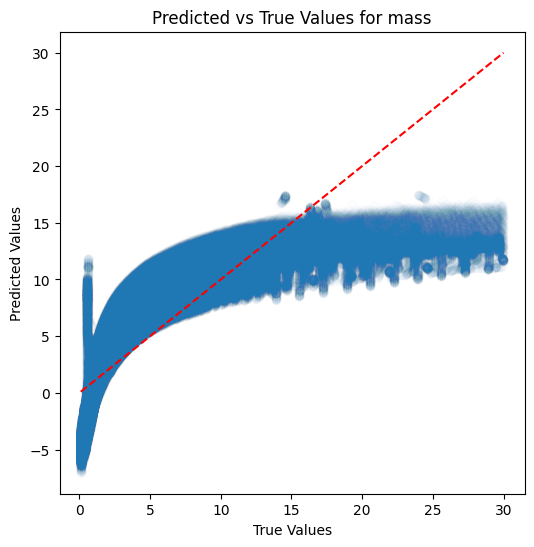

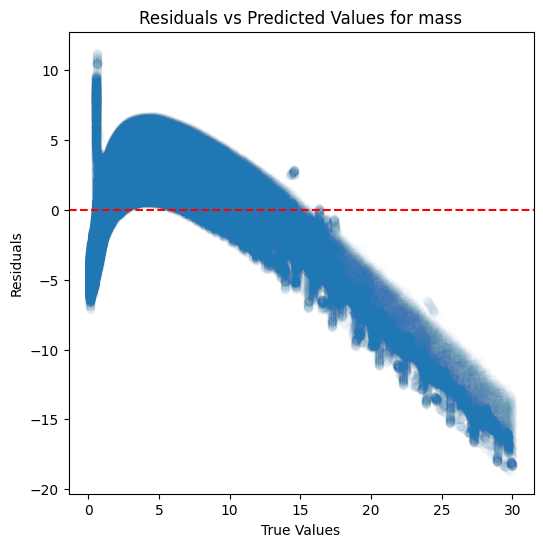

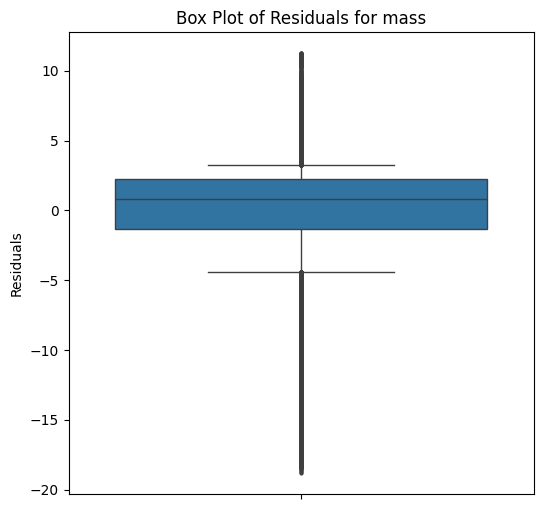

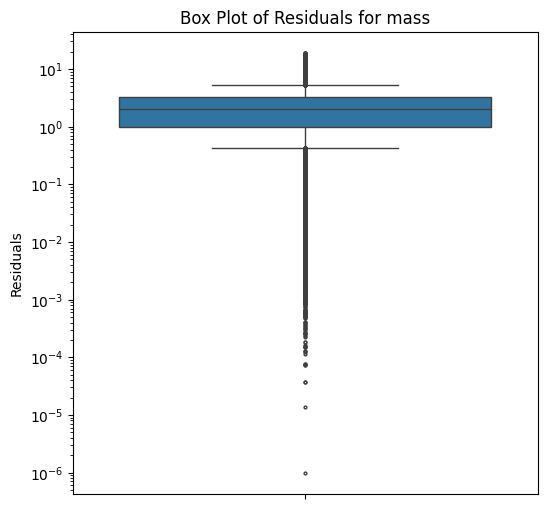

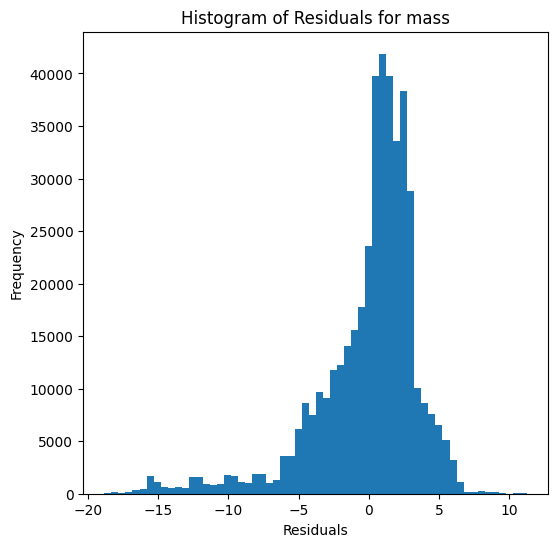

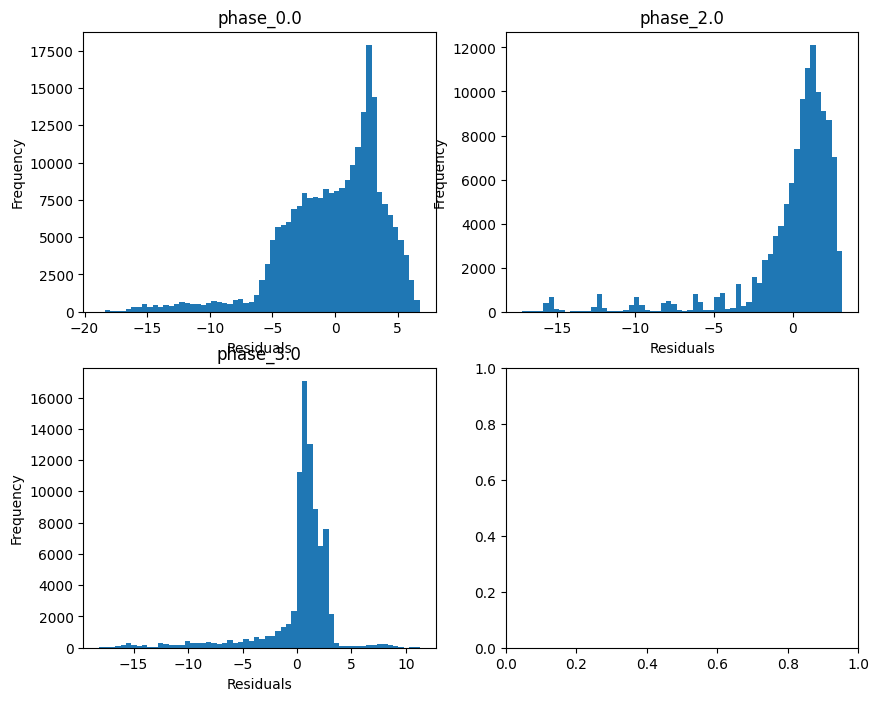

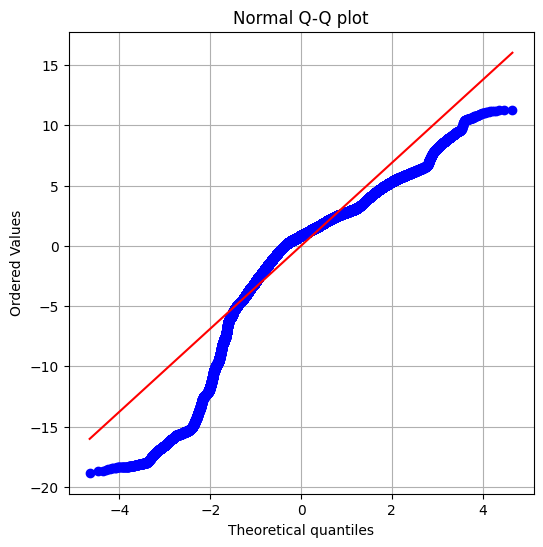

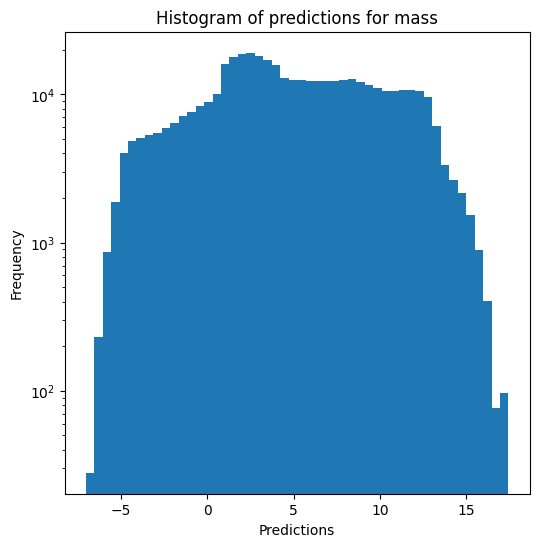

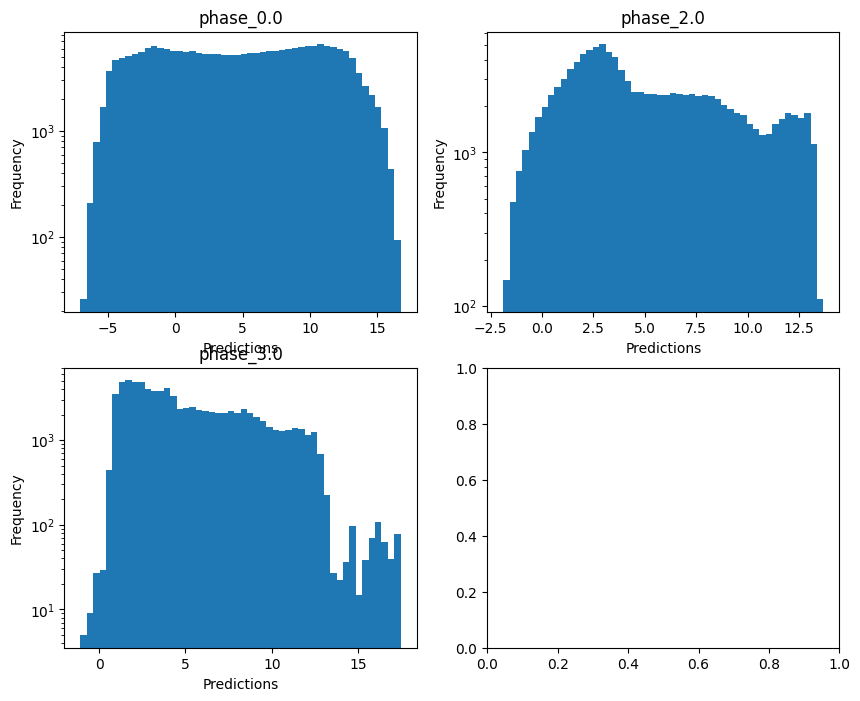

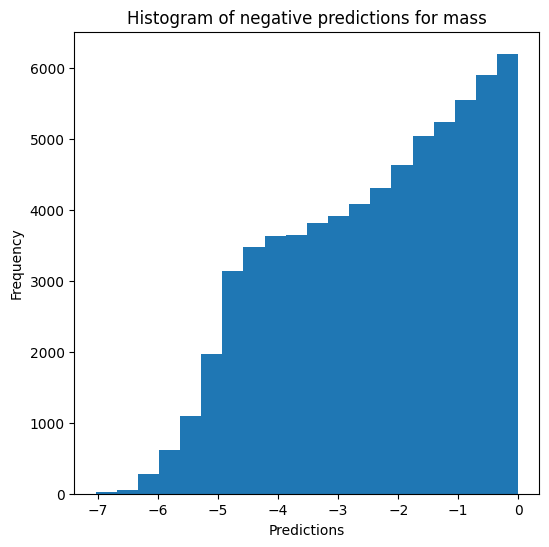


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.0827540579576227
  RVE :  0.9833485877286566
  RMSE :  0.06536757152819228
  MAE :  0.05169068132730123
  MedAE :  0.043826614513058845
  CORR :  0.9916980887873753
  MAX_ER :  0.22198913622387573
  Percentiles : 
    75th percentile :  0.07880686897907088
    90th percentile :  0.10961028922125854
    95th percentile :  0.1264620240866488
    99th percentile :  0.15581527590952254

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9812242174606677
  RMSE :  0.06390623781293282
  MAE :  0.04911116678442271
  MedAE :  0.03860285690378118
  CORR :  0.9917120850902722
  MAX_ER :  0.25332435335892356
  Percentiles : 
    75th percentile :  0.07063163725732546
    90th percentile :  0.1045293035109335
    95th percentile :  0.12773489024975473
    99th percentile :  0.18654454318863029

radius results for the phase cat

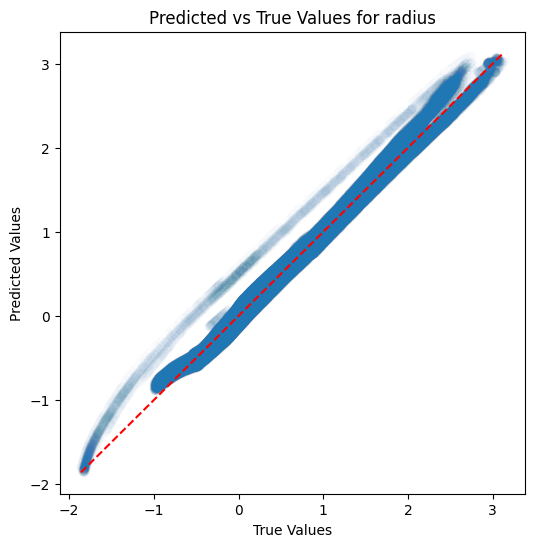

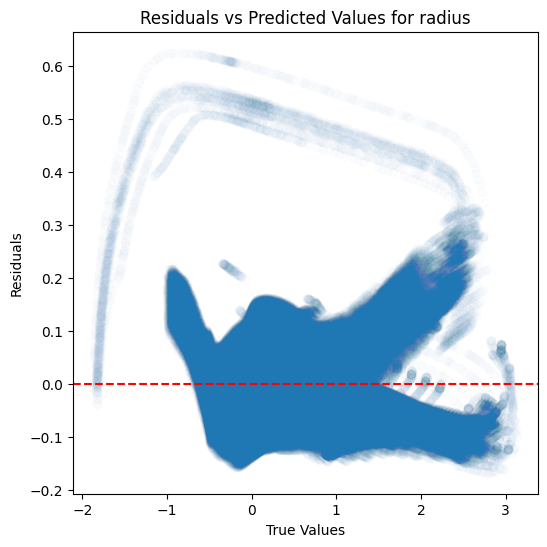

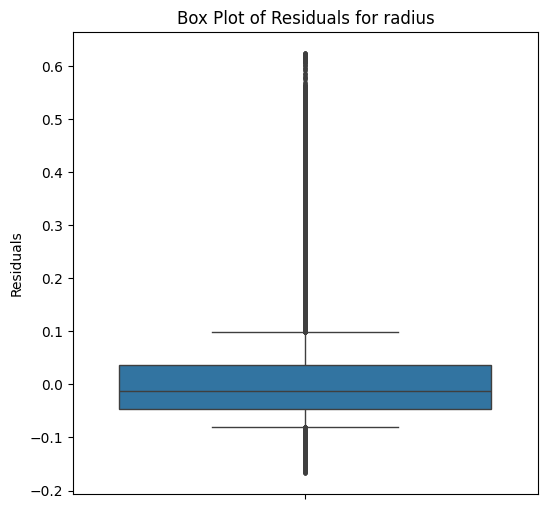

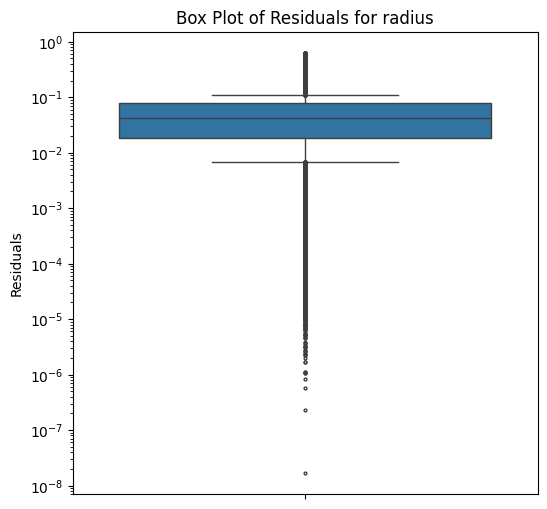

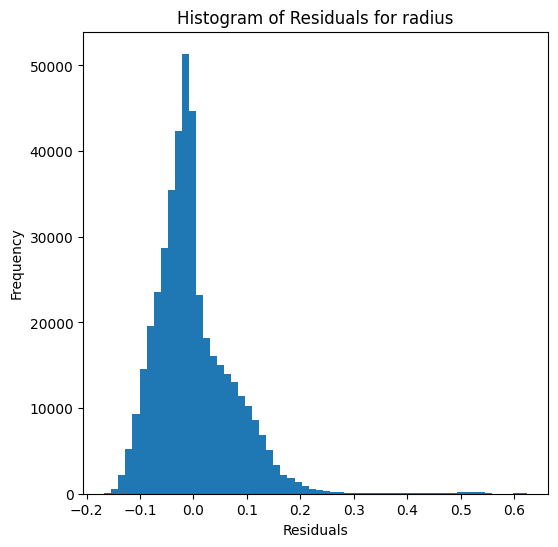

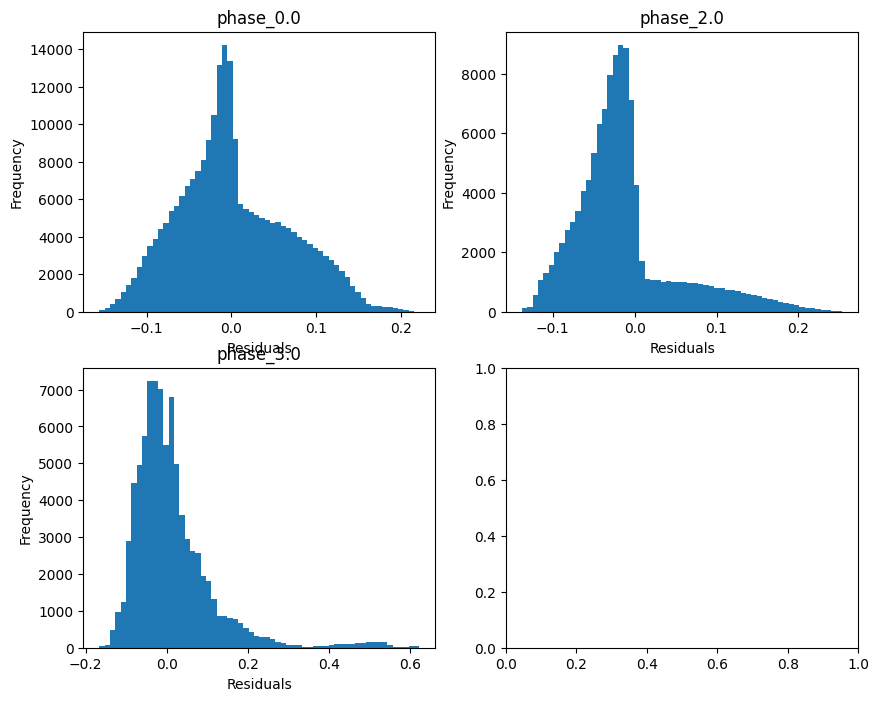

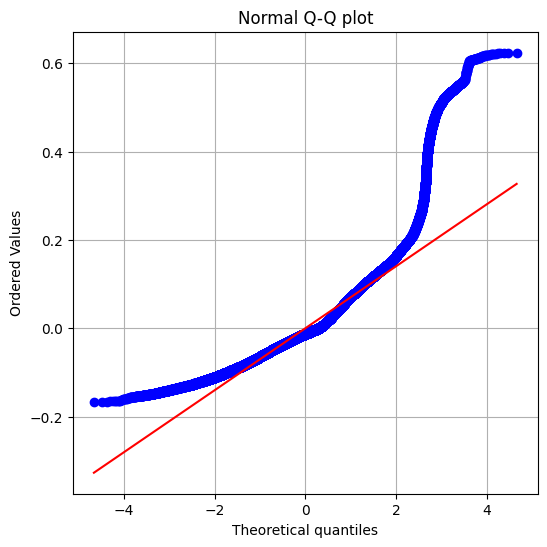

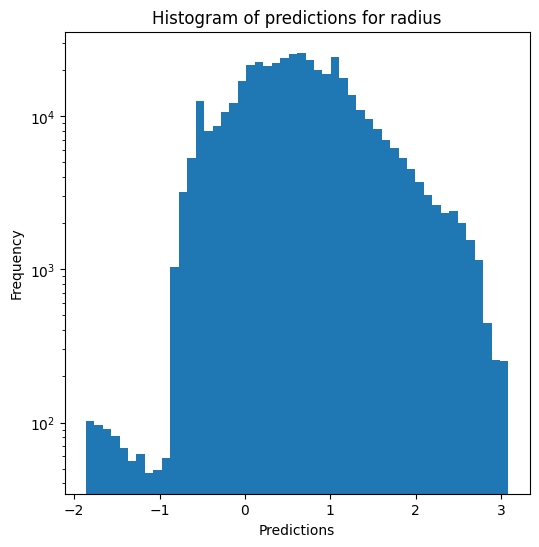

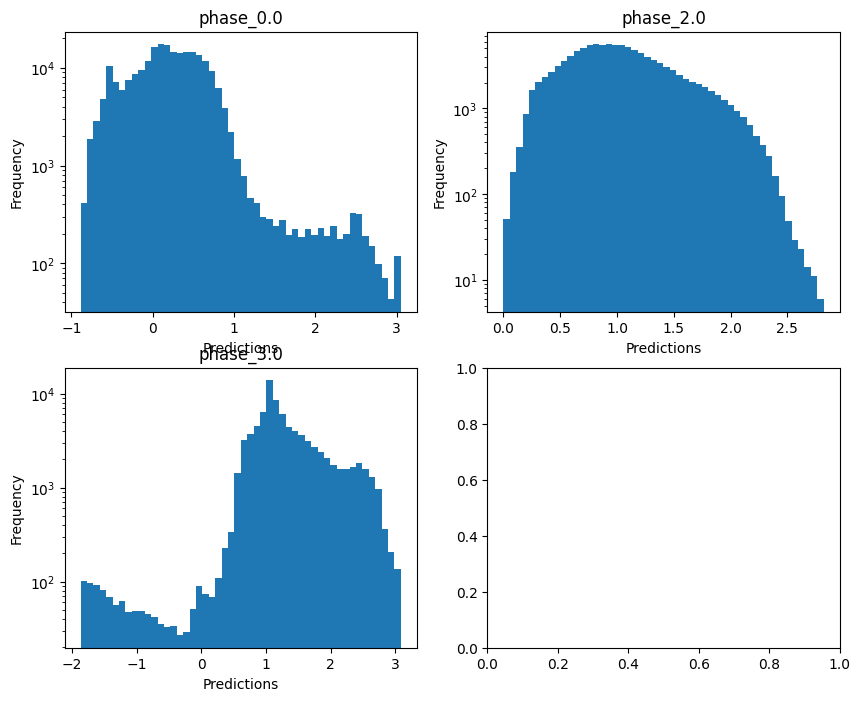

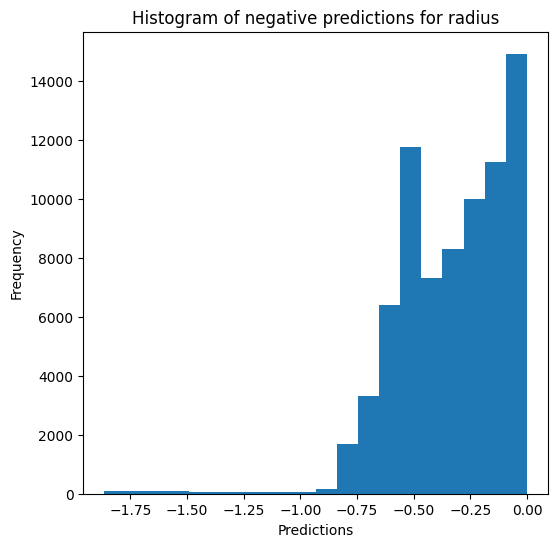

Saving predictions and results...


In [12]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=True, show=True)

### Decision tree

In [13]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_30 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.099998052173157 - 29.999136881366123
  RVE :  0.9989288712610146
  RMSE :  0.20479451317293032
  MAE :  0.0370962150739012
  MedAE :  0.004833033082474181
  CORR :  0.9994644970550393
  MAX_ER :  12.04844243089262
  Percentiles : 
    75th percentile :  0.01849621807622212
    90th percentile :  0.06886194828665104
    95th percentile :  0.1400967619517594
    99th percentile :  0.5168024801519175

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 29.67887151062485
  RVE :  0.9998856763326173
  RMSE :  0.06333240179353944
  MAE :  0.007766881524781867
  MedAE :  0.00029192157563162624
  CORR :  0.9999428516541571
  MAX_ER :  9.179017754221904
  Percentiles : 
    75th percentile :  0.0050338167760333175
    90th percentile :  0.021929789675866437

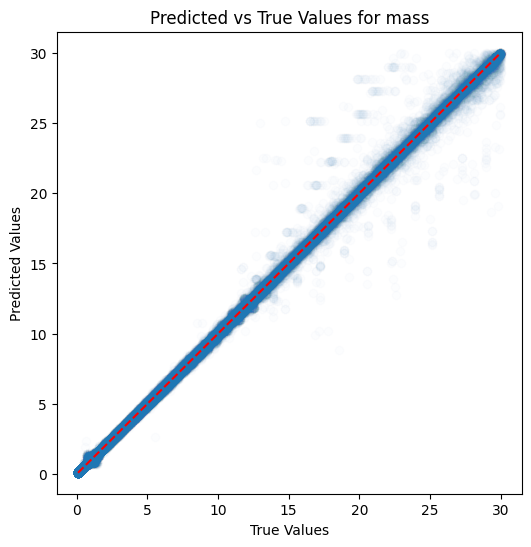

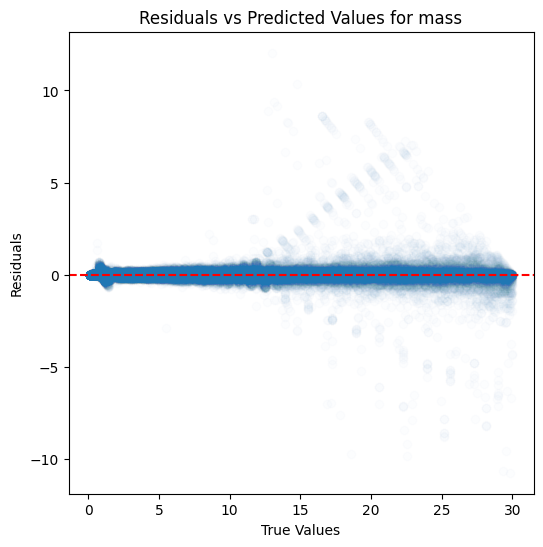

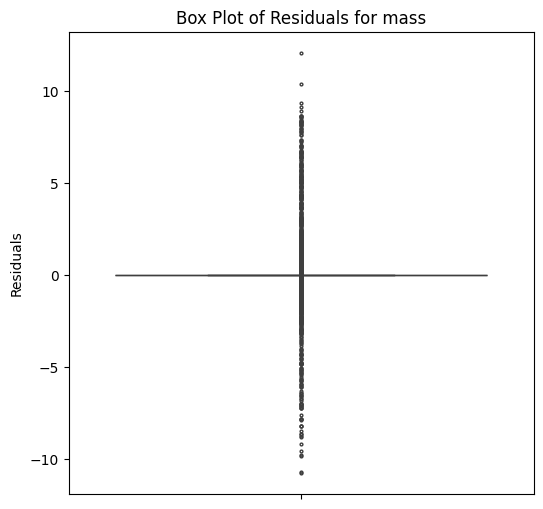

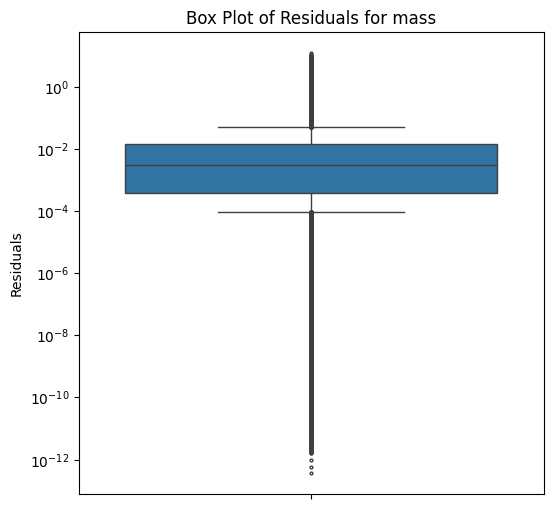

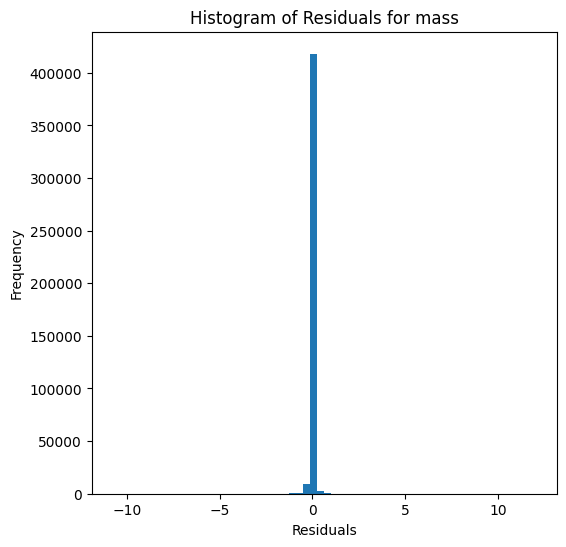

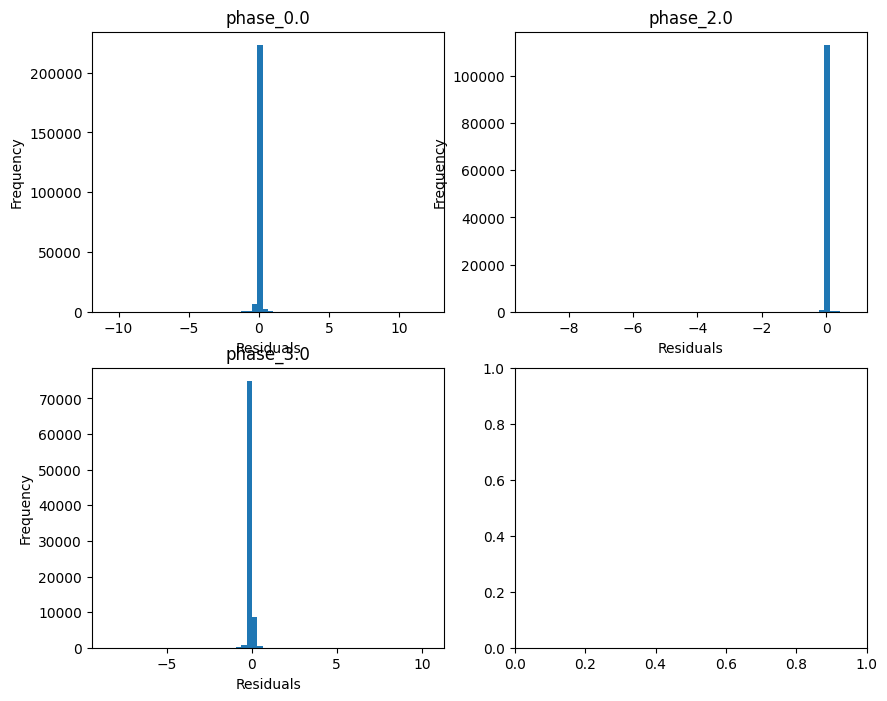

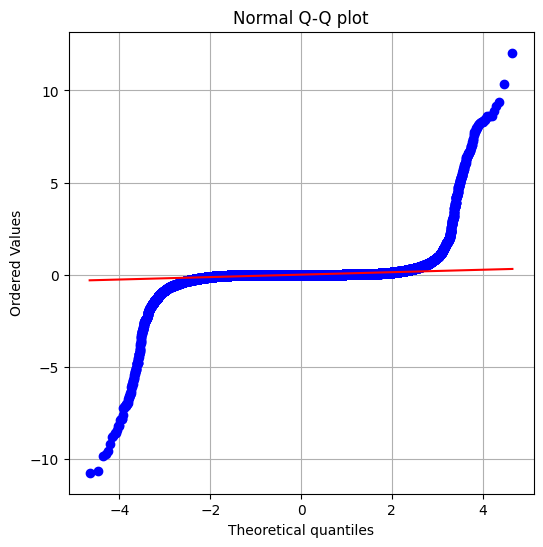

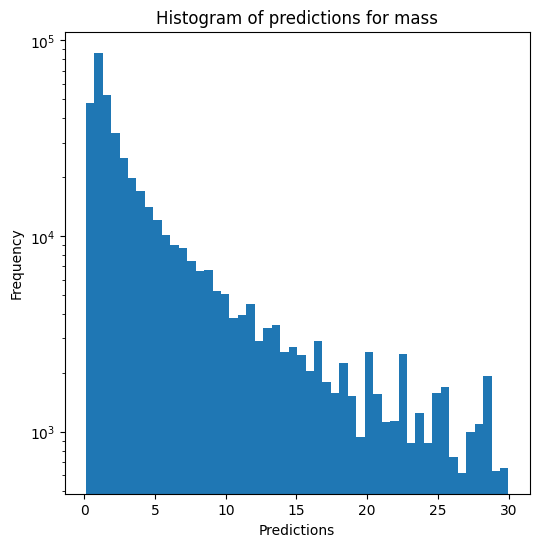

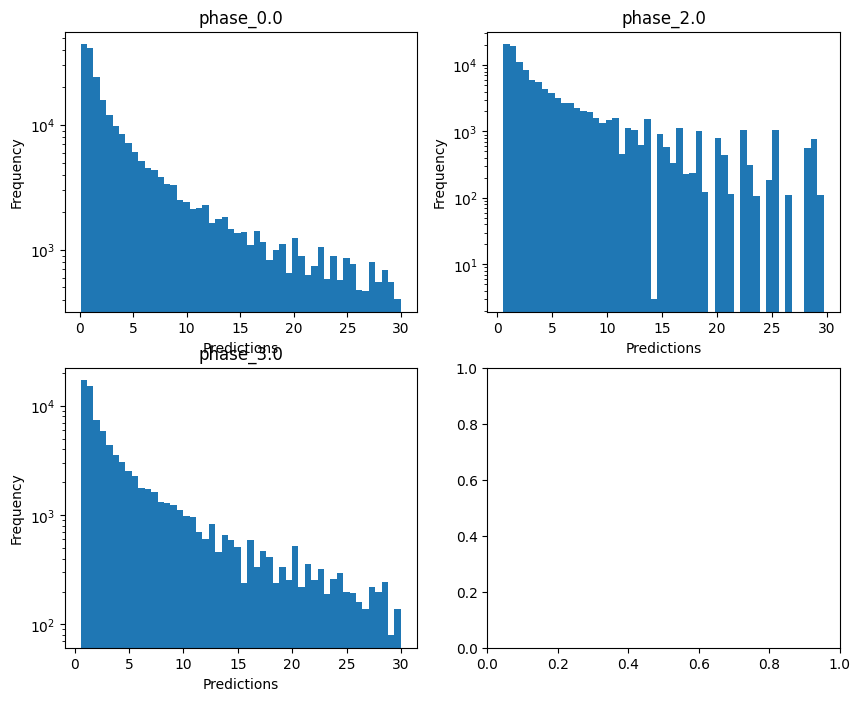


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.0827540579576227
  RVE :  0.9998036006117262
  RMSE :  0.0070988862741955035
  MAE :  0.0039865789953253085
  MedAE :  0.0024238304529700383
  CORR :  0.9999017978007643
  MAX_ER :  0.5140943028519352
  Percentiles : 
    75th percentile :  0.004855472077110377
    90th percentile :  0.008824826496599797
    95th percentile :  0.01246585214481121
    99th percentile :  0.026590964628484454

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9994948425223688
  RMSE :  0.010237794069864602
  MAE :  0.006976767883415538
  MedAE :  0.005629037287626204
  CORR :  0.9997492057116859
  MAX_ER :  0.8341740650426792
  Percentiles : 
    75th percentile :  0.00949369617548168
    90th percentile :  0.01362792371110442
    95th percentile :  0.016882245615083783
    99th percentile :  0.03150901884417474

radius results for t

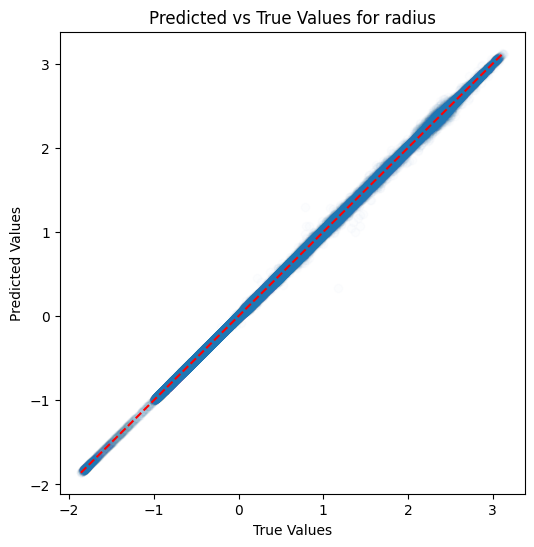

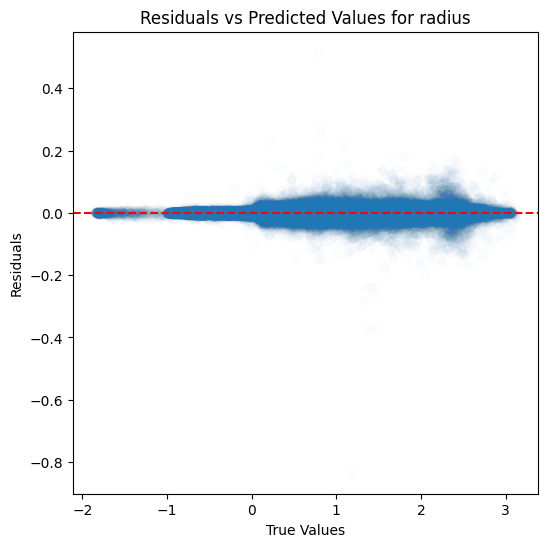

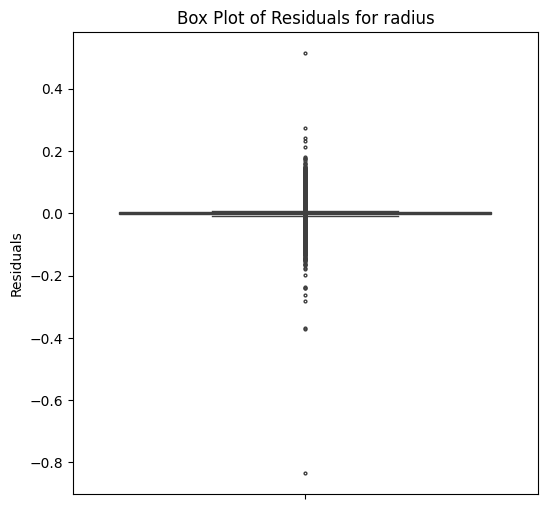

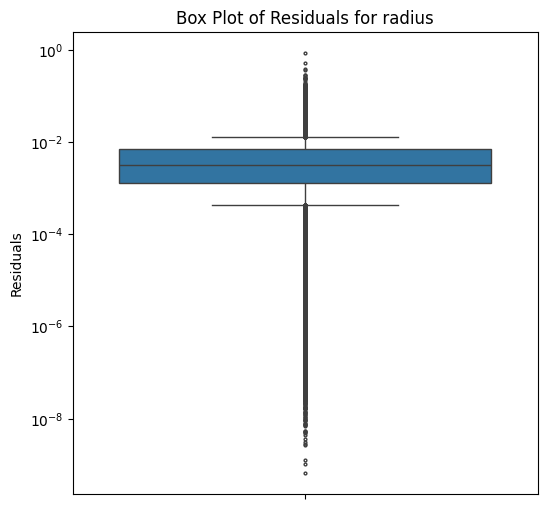

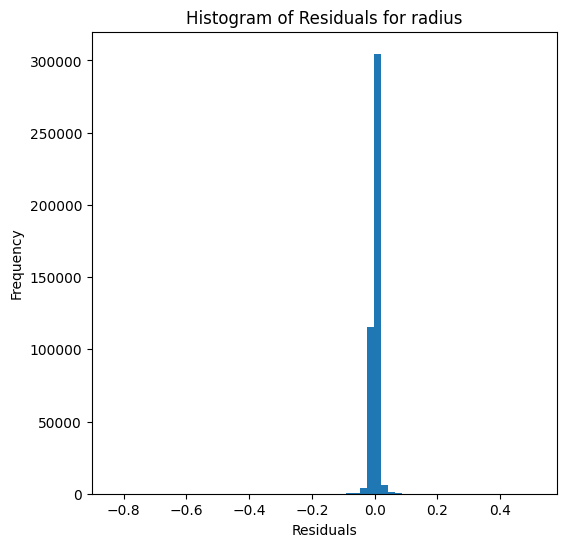

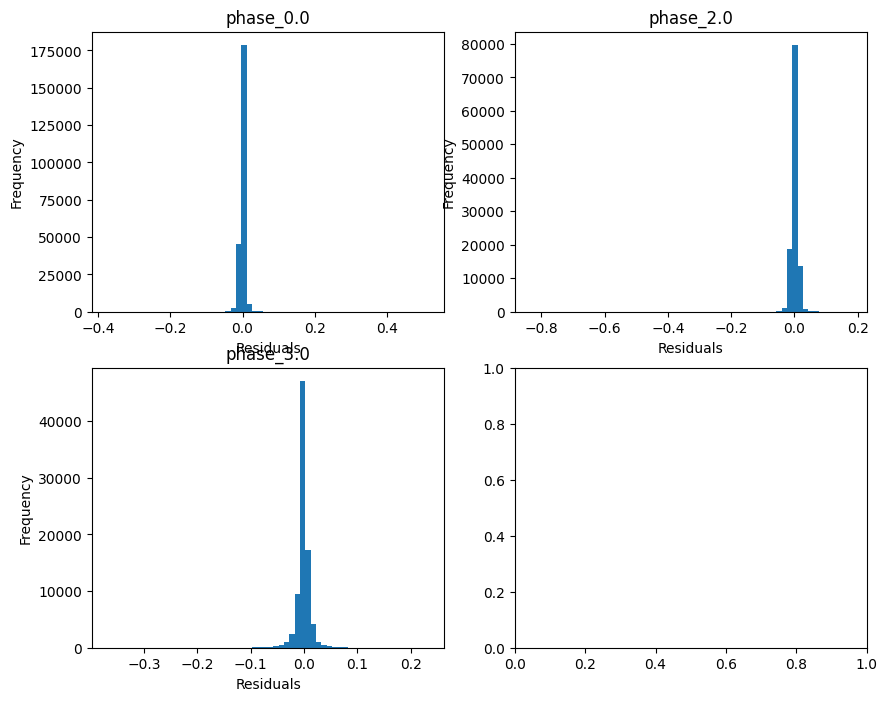

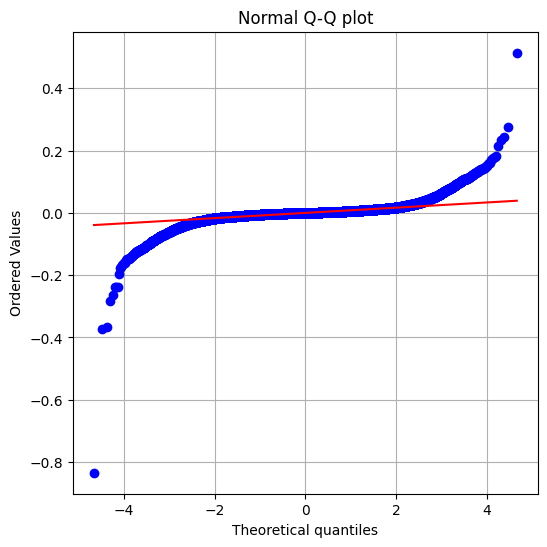

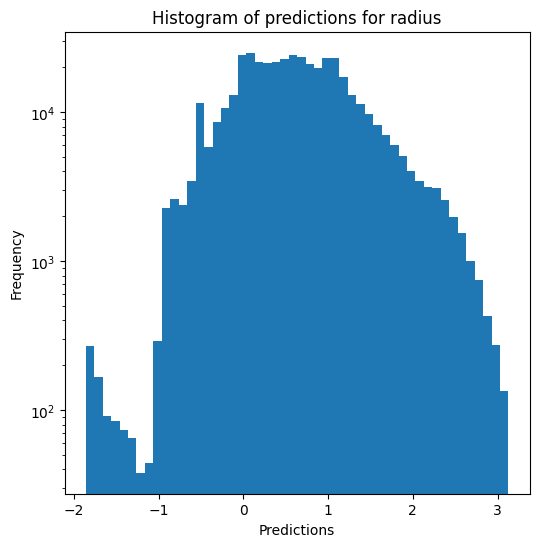

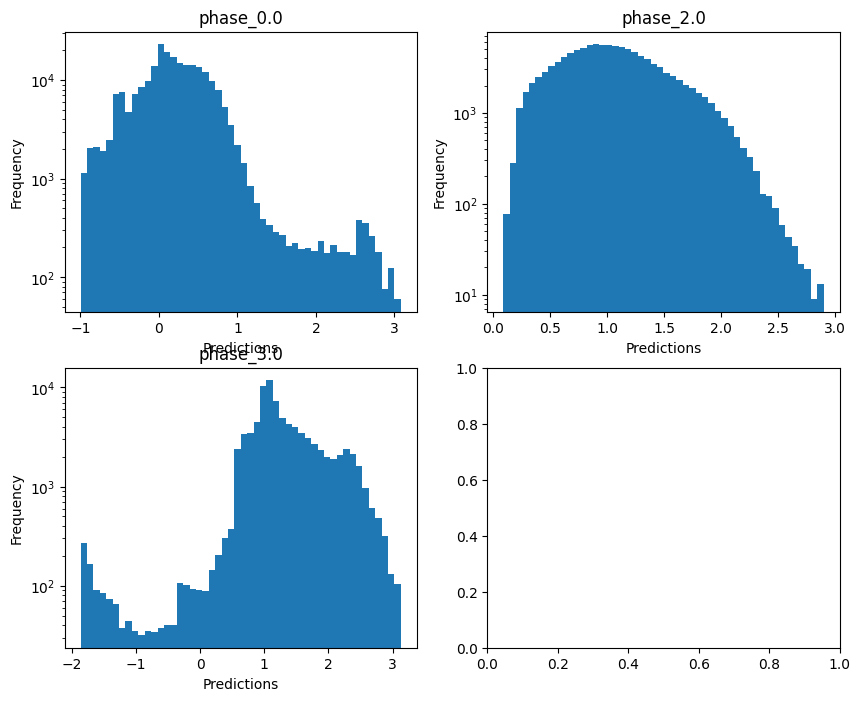

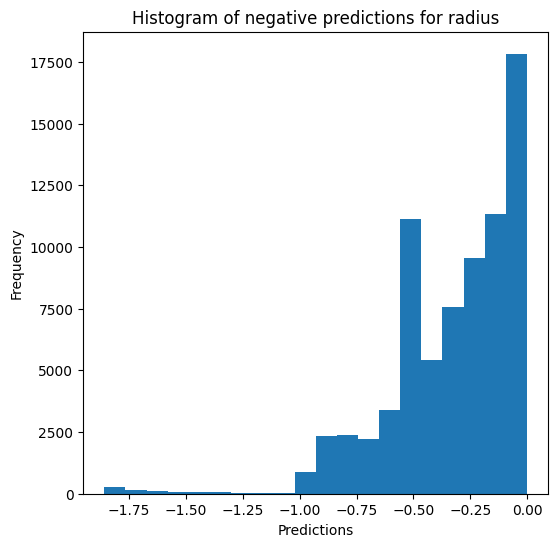

Saving predictions and results...


In [14]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=True, show=True)

### K-nearest neighbours

In [15]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_30 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.099998052173157 - 29.999136881366123
  RVE :  0.9982834222549964
  RMSE :  0.25937800608796263
  MAE :  0.06437274262130681
  MedAE :  0.008397858904385935
  CORR :  0.9991558637442133
  MAX_ER :  7.274123107442772
  Percentiles : 
    75th percentile :  0.03339350345016778
    90th percentile :  0.12122608111173865
    95th percentile :  0.26538452570325627
    99th percentile :  1.0164205274639178

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 29.67887151062485
  RVE :  0.9998926681676554
  RMSE :  0.06142220794191277
  MAE :  0.020408799453852138
  MedAE :  0.003801213620794275
  CORR :  0.9999463625075689
  MAX_ER :  2.365722589923628
  Percentiles : 
    75th percentile :  0.01524738019803129
    90th percentile :  0.05396422345098334
  

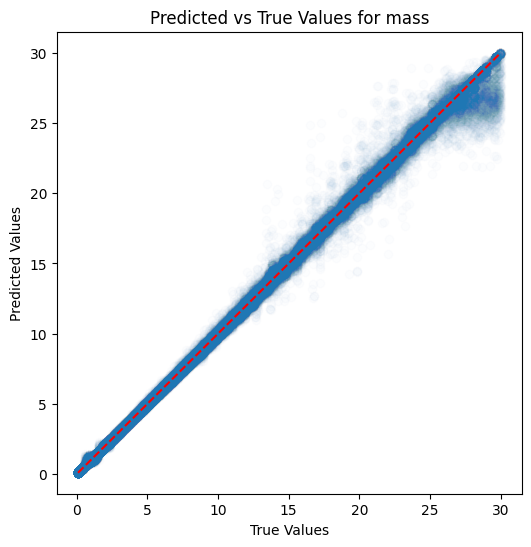

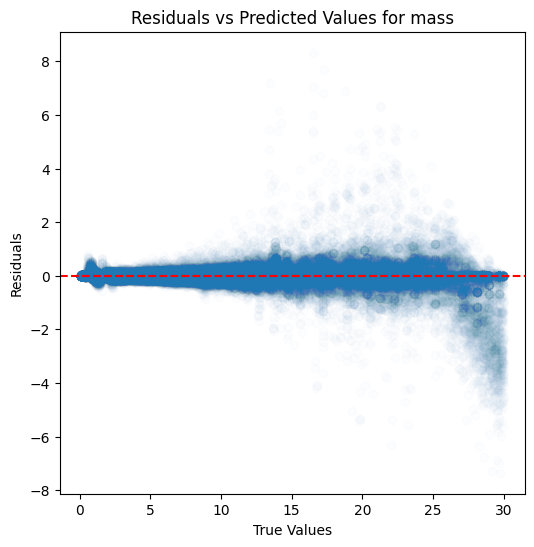

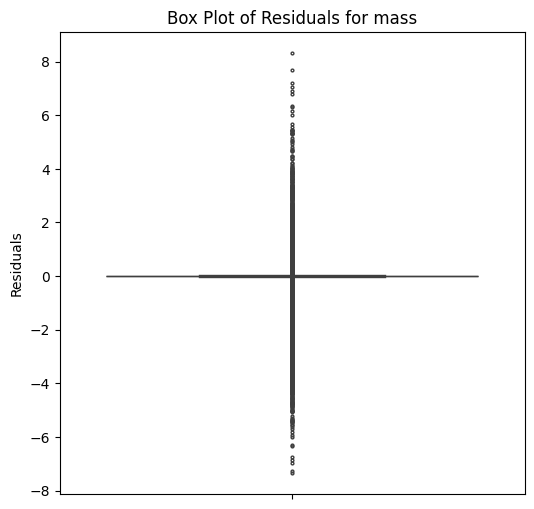

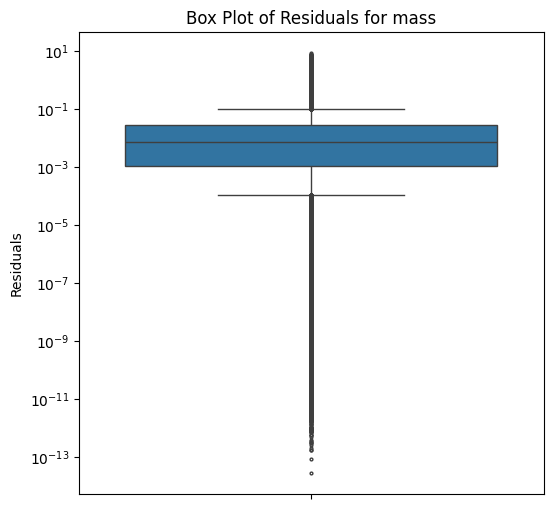

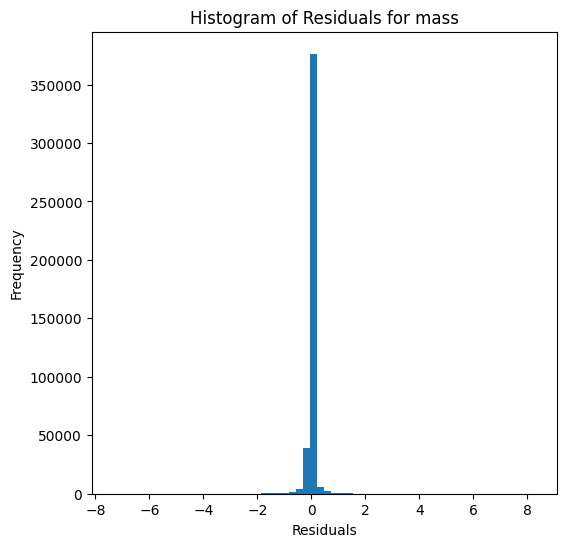

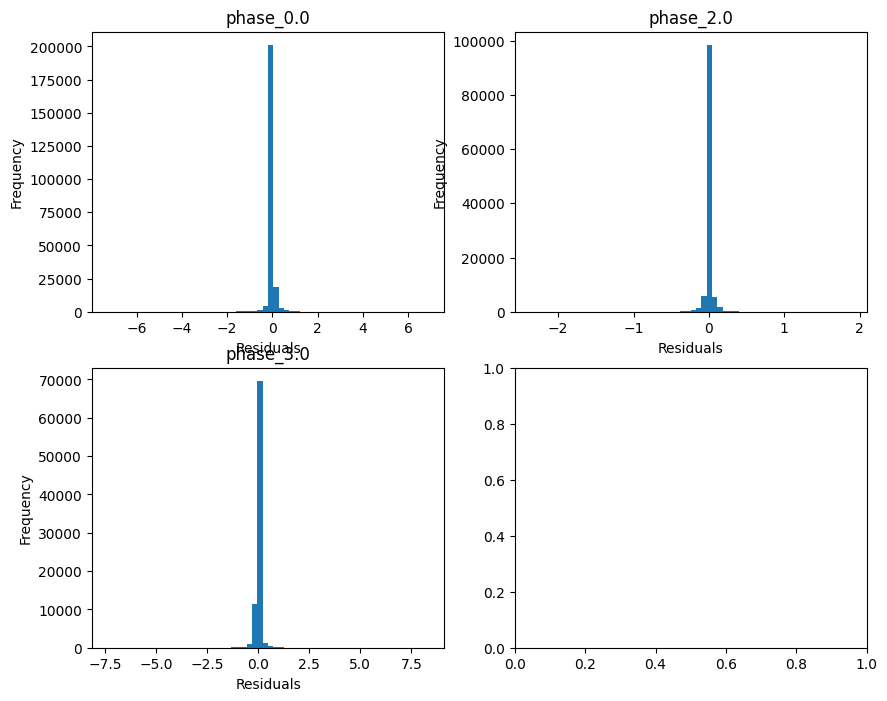

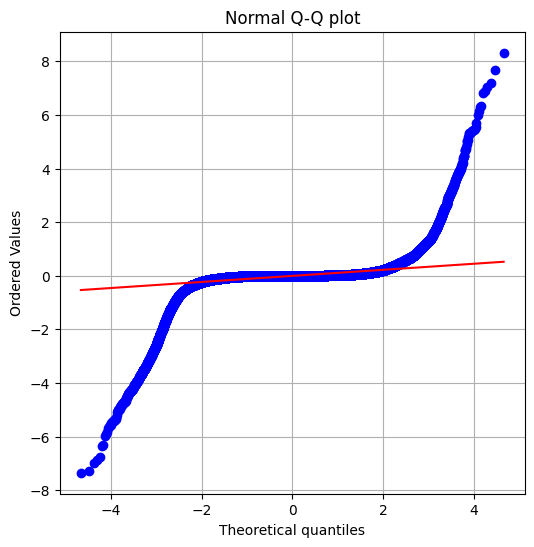

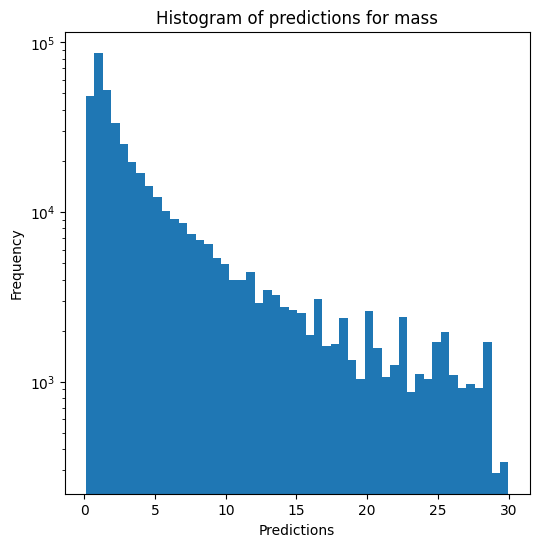

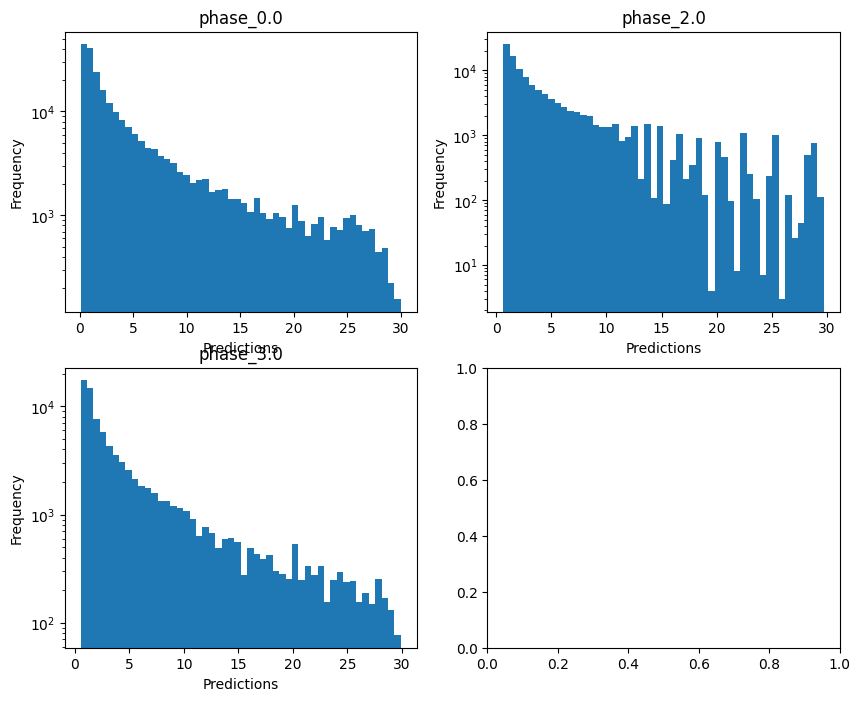


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.0827540579576227
  RVE :  0.9998692256870981
  RMSE :  0.005790859814080516
  MAE :  0.0037649204541067645
  MedAE :  0.0024308009339409214
  CORR :  0.999934934003084
  MAX_ER :  0.08158906393655352
  Percentiles : 
    75th percentile :  0.004716178147904851
    90th percentile :  0.008613440017350472
    95th percentile :  0.011985099249385518
    99th percentile :  0.022001381754273585

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.999896732789779
  RMSE :  0.00462708959675789
  MAE :  0.0034746355786746423
  MedAE :  0.002652679339220587
  CORR :  0.9999483907470569
  MAX_ER :  0.05680804827445396
  Percentiles : 
    75th percentile :  0.004771505237002149
    90th percentile :  0.007714548602680629
    95th percentile :  0.00961679011195125
    99th percentile :  0.013488090647061222

radius results for

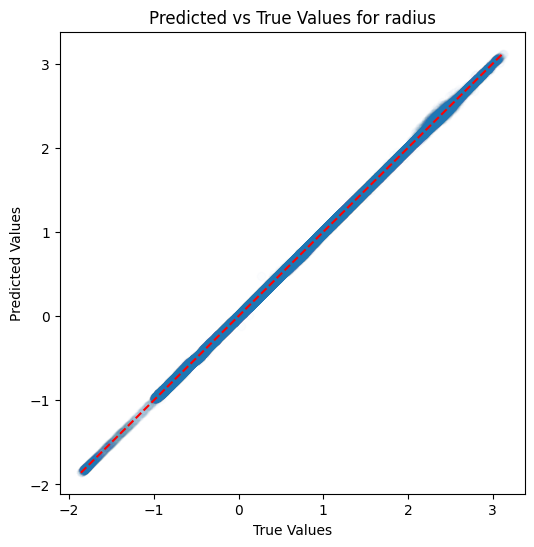

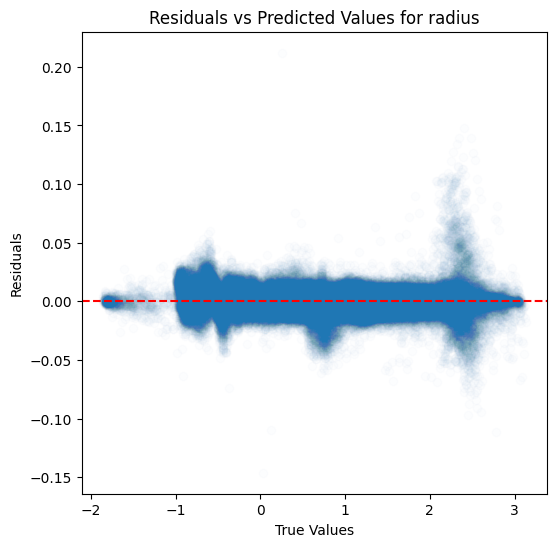

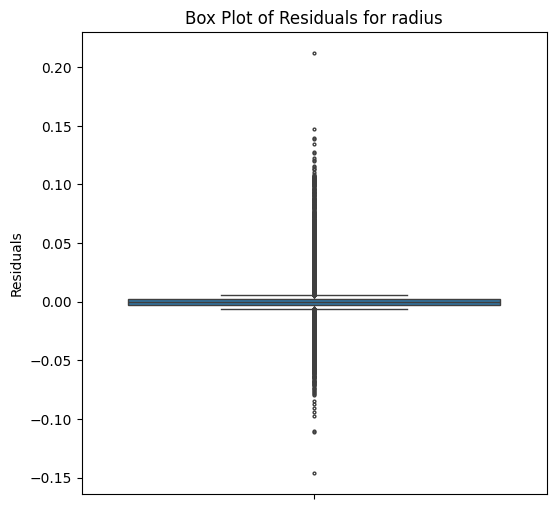

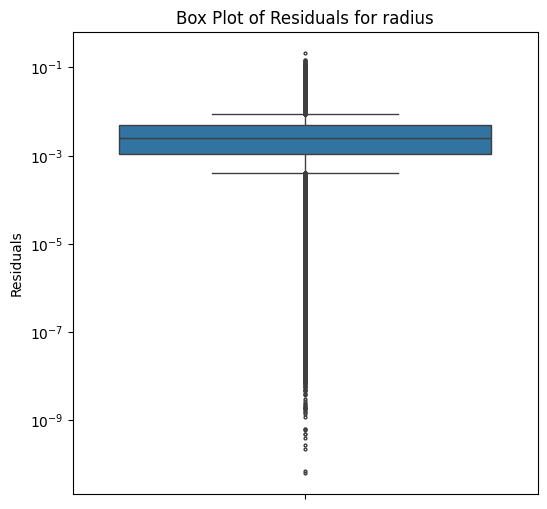

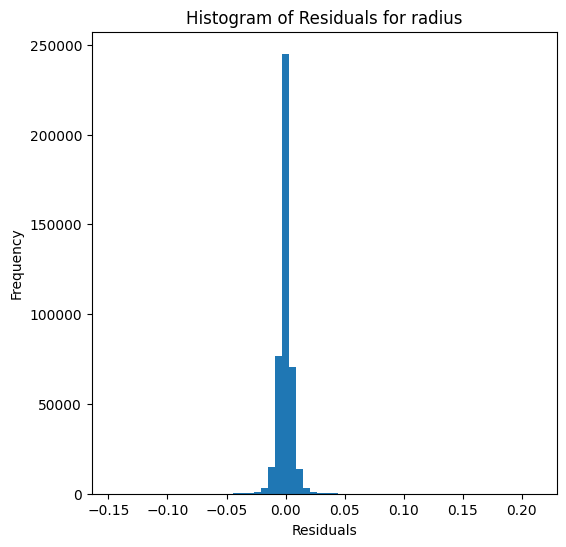

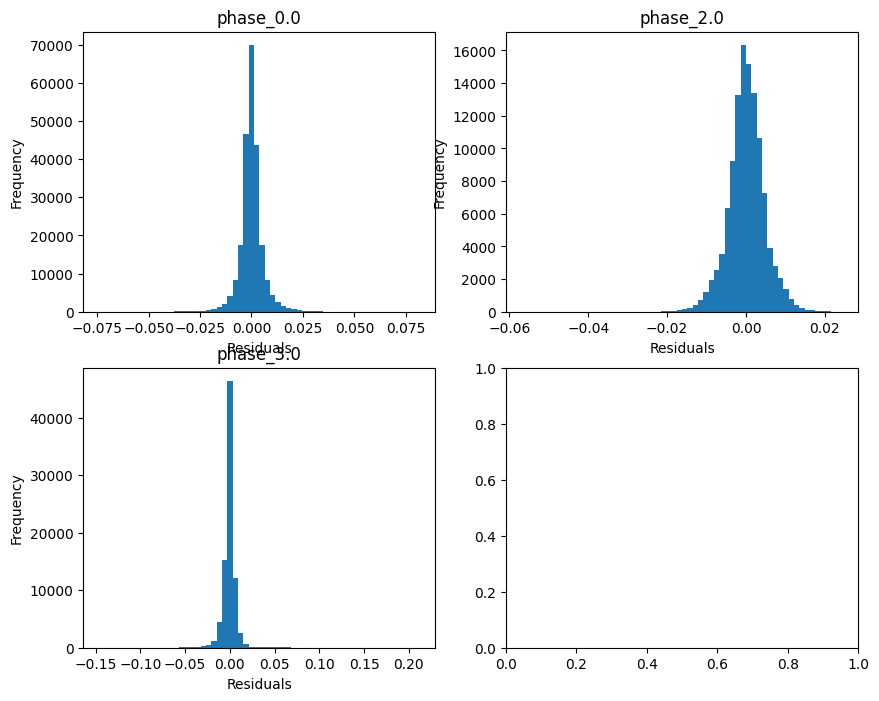

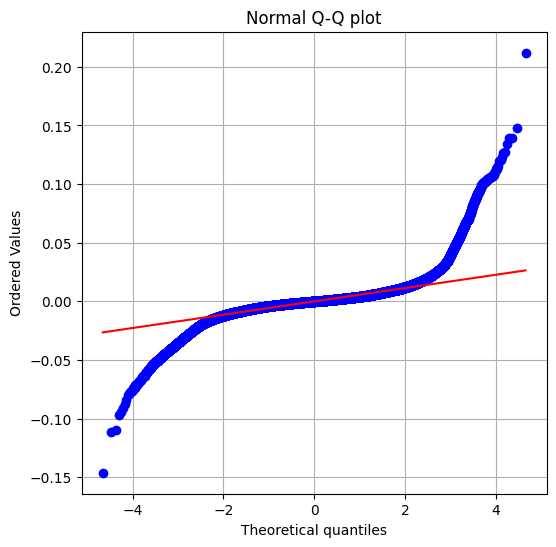

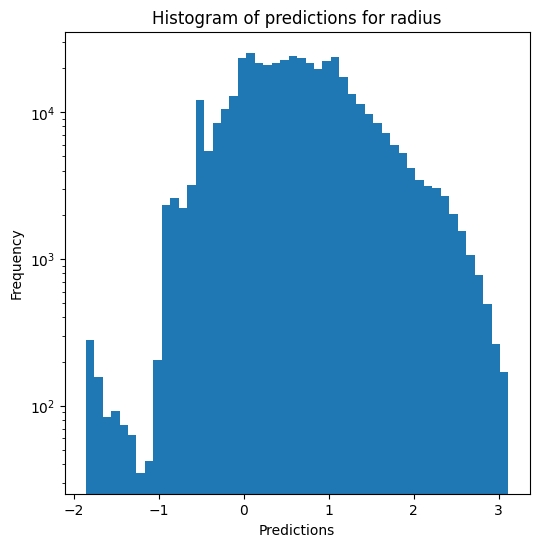

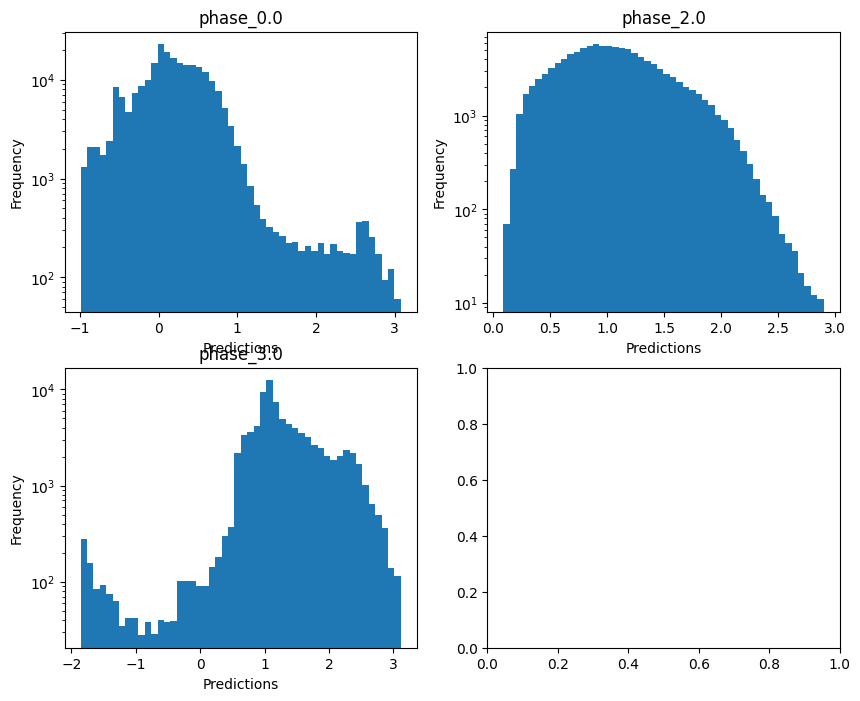

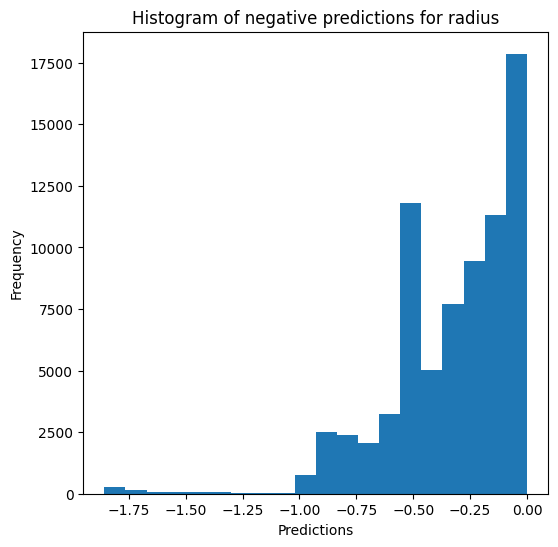

Saving predictions and results...


In [16]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=True, show=True)

### Random forests

In [17]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_30 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.099998052173157 - 29.999136881366123
  RVE :  0.9995217371179236
  RMSE :  0.13685222105468756
  MAE :  0.02297187959691604
  MedAE :  0.0027996199106907205
  CORR :  0.9997608401017831
  MAX_ER :  6.6550974787690045
  Percentiles : 
    75th percentile :  0.009556487480156584
    90th percentile :  0.03289007744568837
    95th percentile :  0.0755575698641228
    99th percentile :  0.36187381881522906

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 29.67887151062485
  RVE :  0.9999630727520922
  RMSE :  0.03600210348199009
  MAE :  0.008525994540392908
  MedAE :  0.0038726860238362804
  CORR :  0.9999816149877483
  MAX_ER :  5.177953336655193
  Percentiles : 
    75th percentile :  0.009177432959917464
    90th percentile :  0.017911455402540

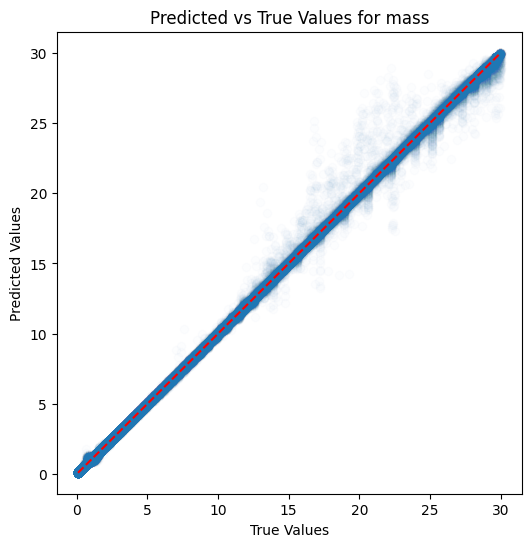

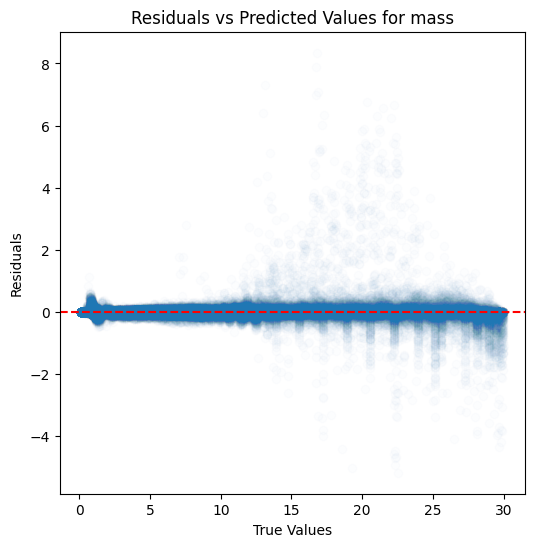

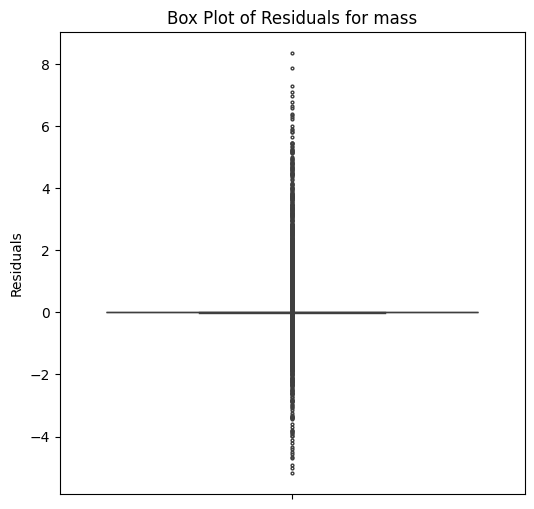

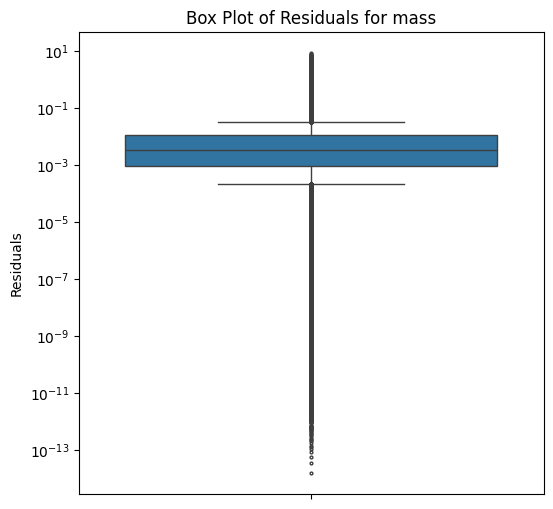

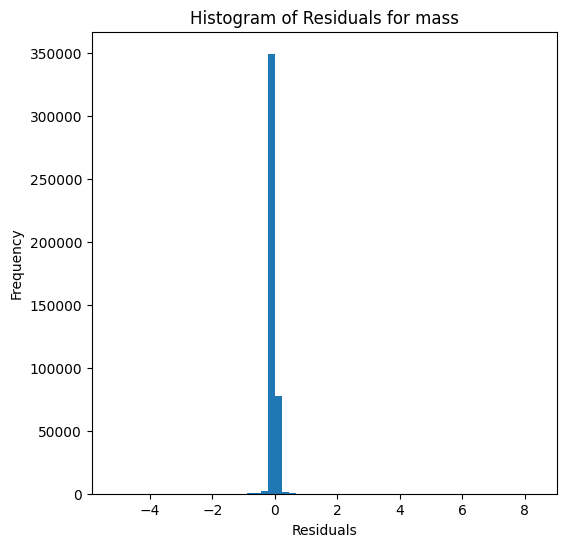

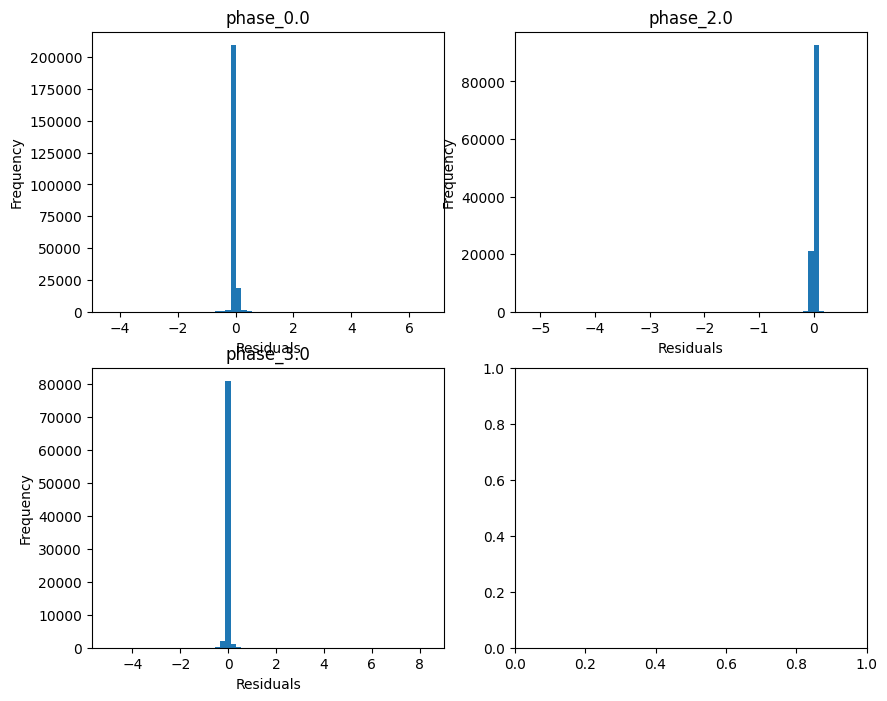

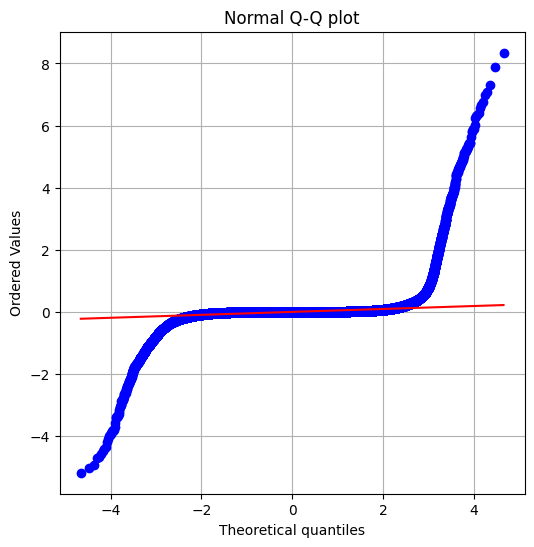

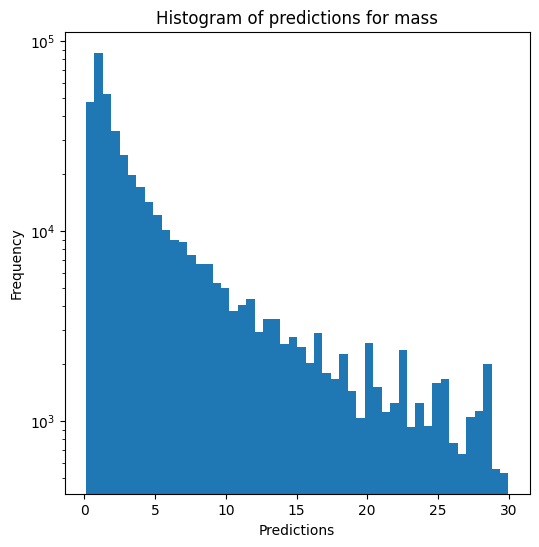

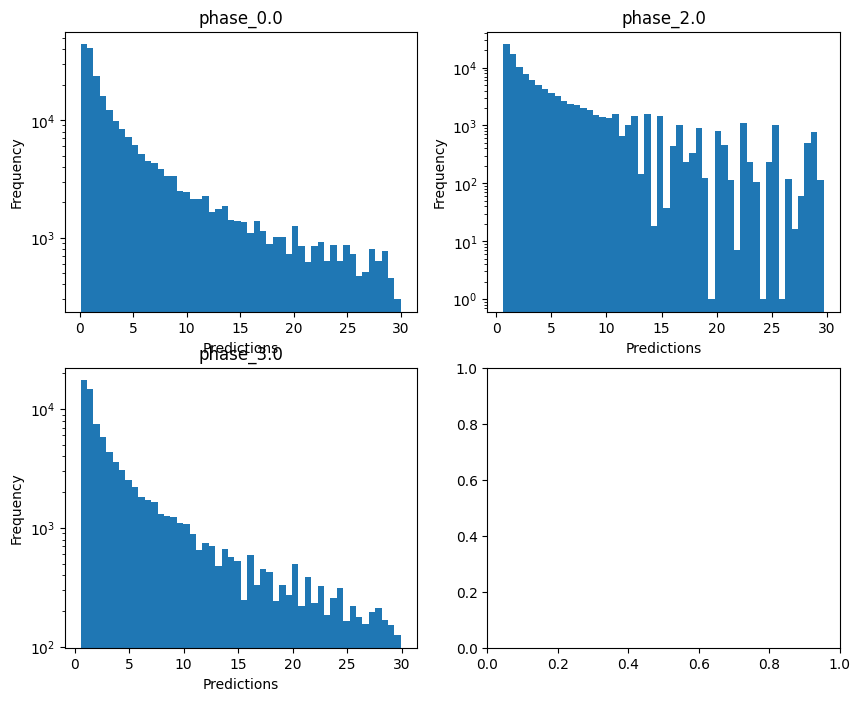


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.0827540579576227
  RVE :  0.9999553925604562
  RMSE :  0.003383653396609602
  MAE :  0.0017487397567619652
  MedAE :  0.0009183059709119146
  CORR :  0.9999776965246363
  MAX_ER :  0.26972546397215036
  Percentiles : 
    75th percentile :  0.002034467326880233
    90th percentile :  0.00404135073005262
    95th percentile :  0.00605556879625599
    99th percentile :  0.012720573196937503

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9999326512662202
  RMSE :  0.003775367391180045
  MAE :  0.00258361744057094
  MedAE :  0.001747377912543091
  CORR :  0.9999674805098631
  MAX_ER :  0.04996632907326015
  Percentiles : 
    75th percentile :  0.003497903127835267
    90th percentile :  0.005933246888709976
    95th percentile :  0.0077952396029674345
    99th percentile :  0.012671131330007683

radius results fo

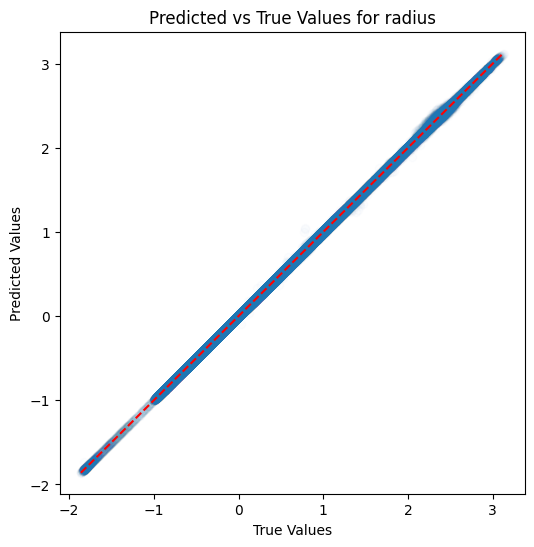

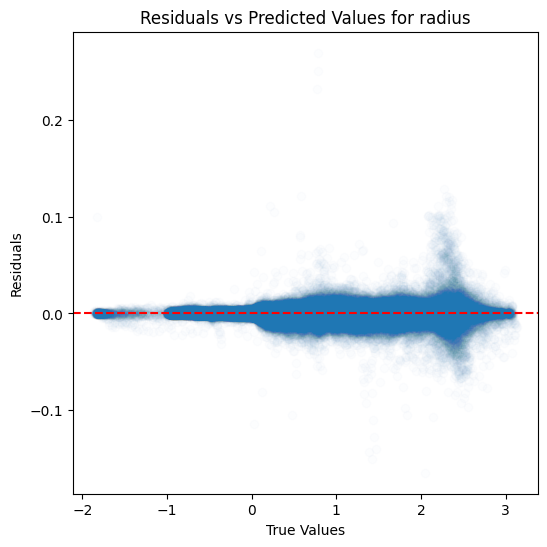

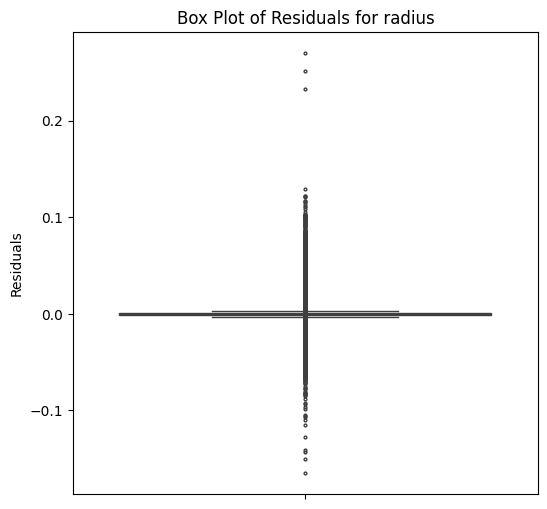

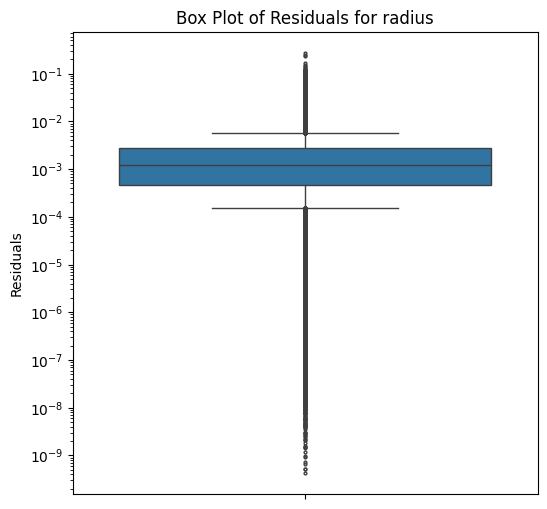

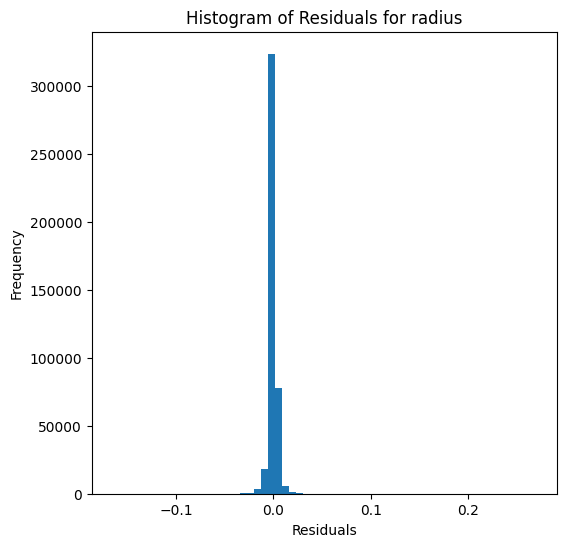

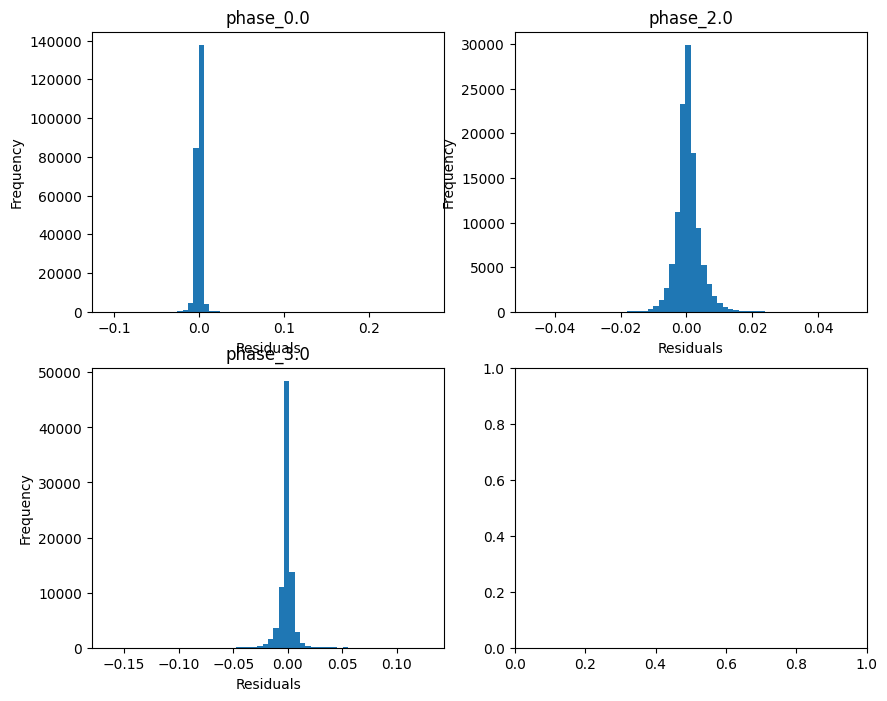

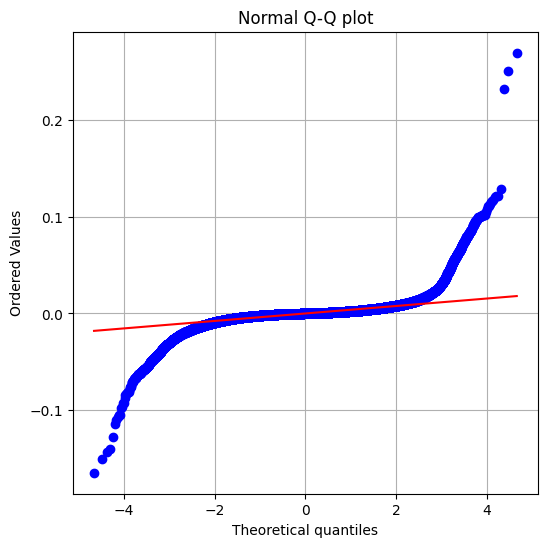

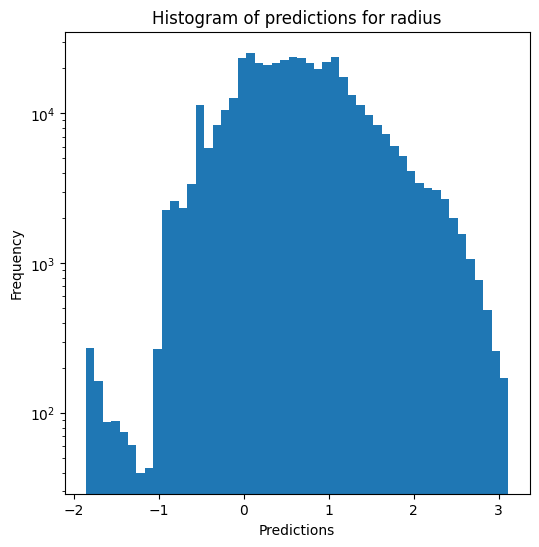

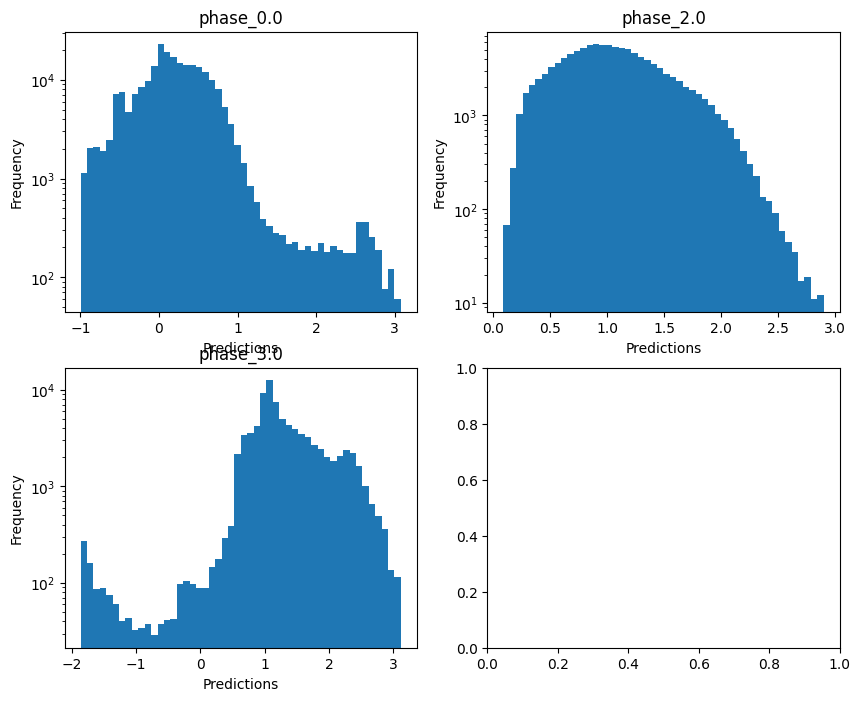

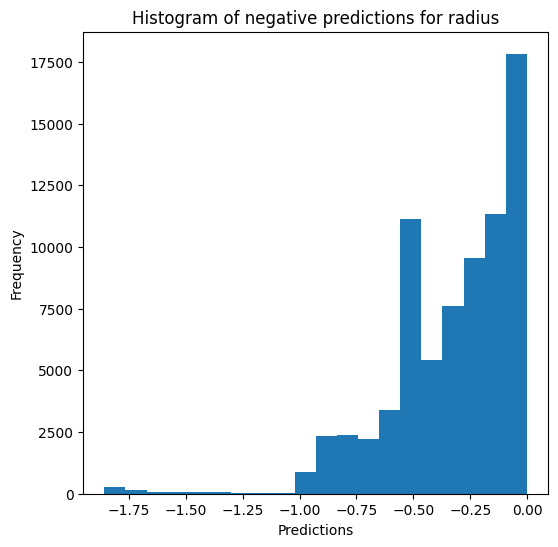

Saving predictions and results...


In [18]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=True, show=True, n_jobs=5)

### XGBoost

In [19]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_30 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.099998052173157 - 29.999136881366123
  RVE :  0.9975490361796097
  RMSE :  0.3098067234614947
  MAE :  0.14257505112937668
  MedAE :  0.05550889952113919
  CORR :  0.9987741345996765
  MAX_ER :  6.026359547816558
  Percentiles : 
    75th percentile :  0.14441541084211784
    90th percentile :  0.33701159506723644
    95th percentile :  0.5642196051477725
    99th percentile :  1.3589695768097734

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 29.67887151062485
  RVE :  0.999688666857799
  RMSE :  0.1069132310207098
  MAE :  0.06198712841112408
  MedAE :  0.03476289684299427
  CORR :  0.9998448966574918
  MAX_ER :  3.802174416275264
  Percentiles : 
    75th percentile :  0.07674382279283676
    90th percentile :  0.13985692097700836
    95th percentile :  0.204

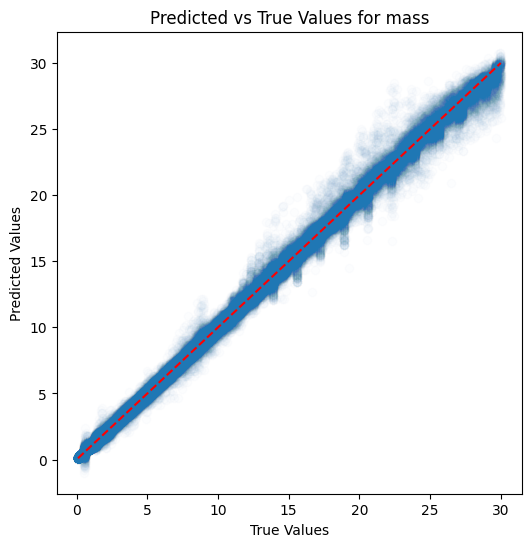

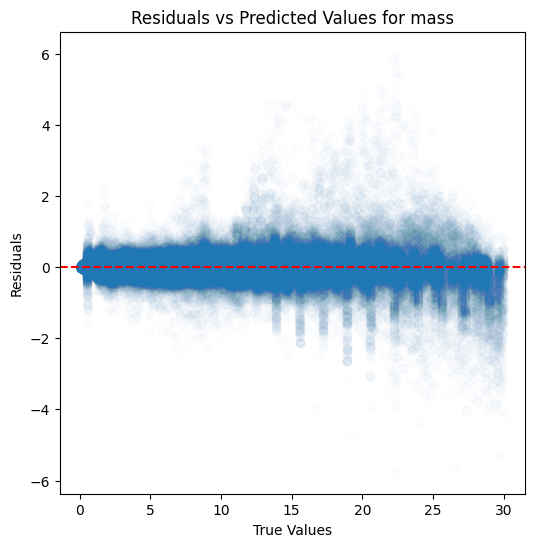

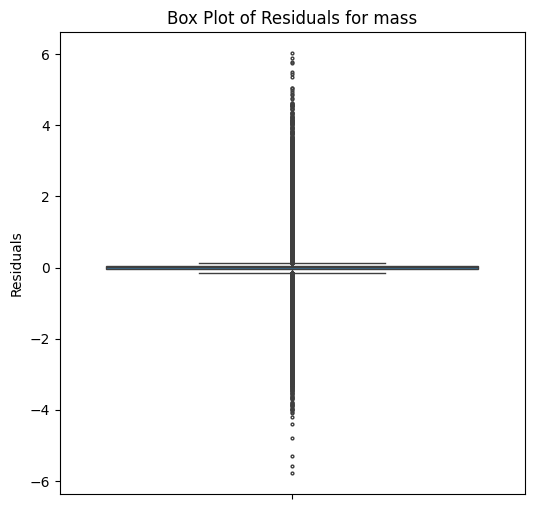

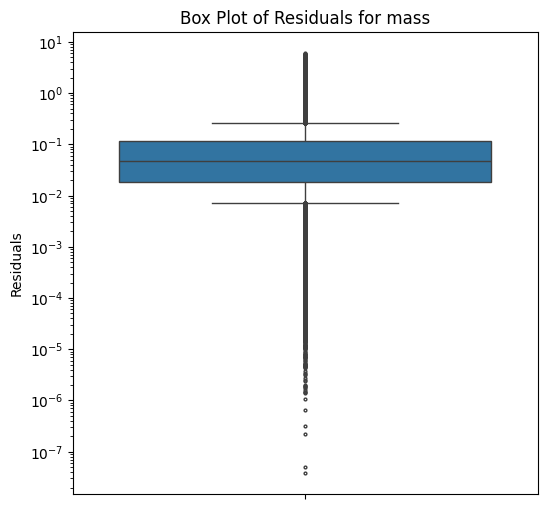

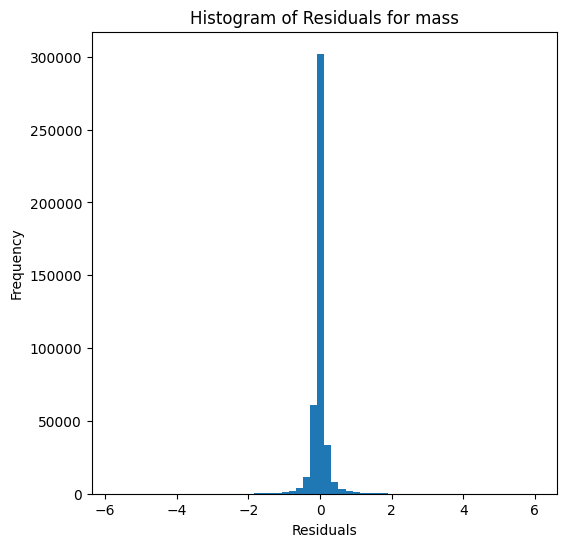

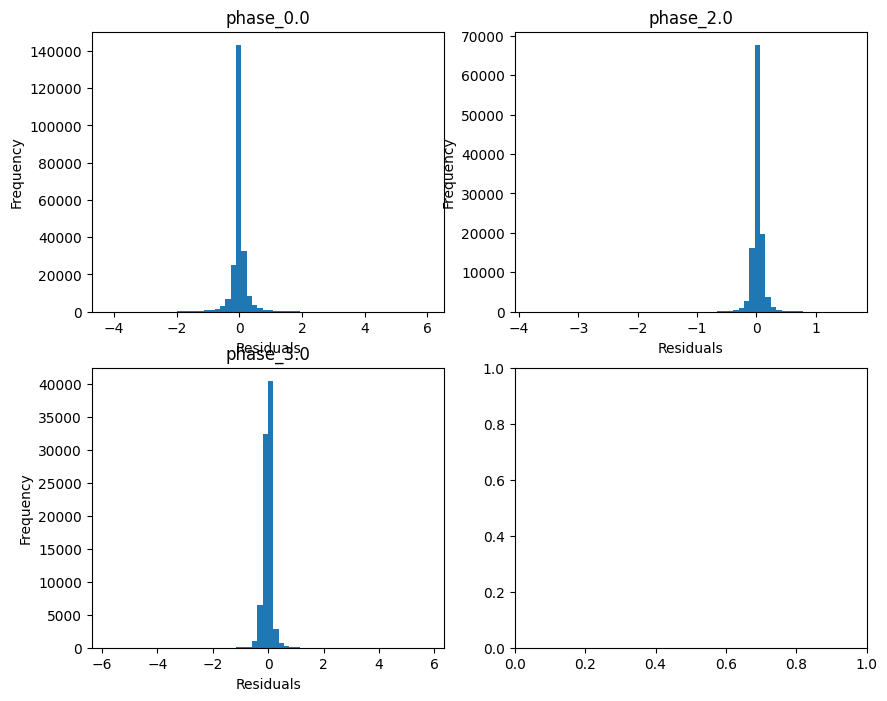

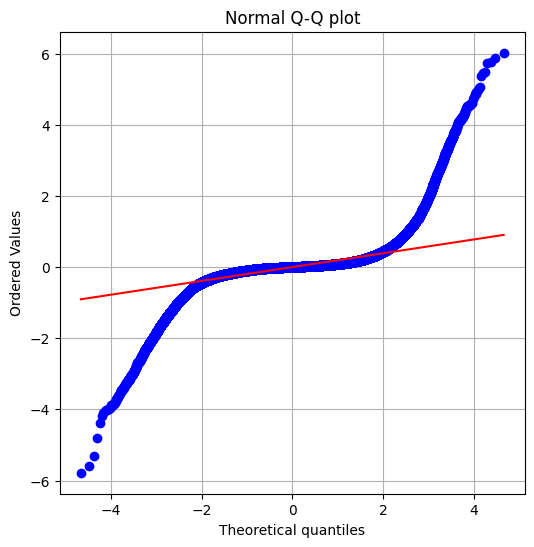

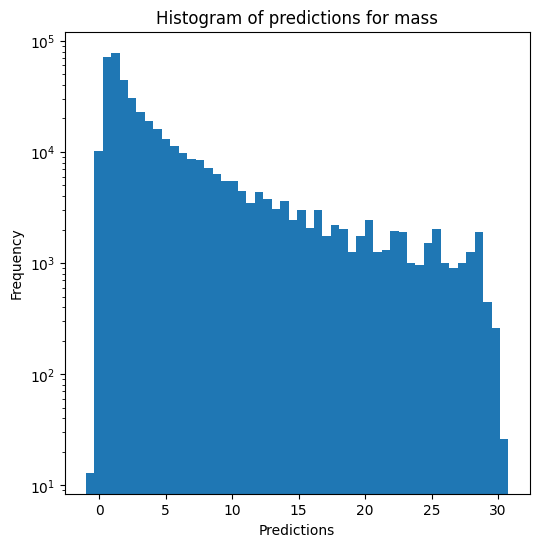

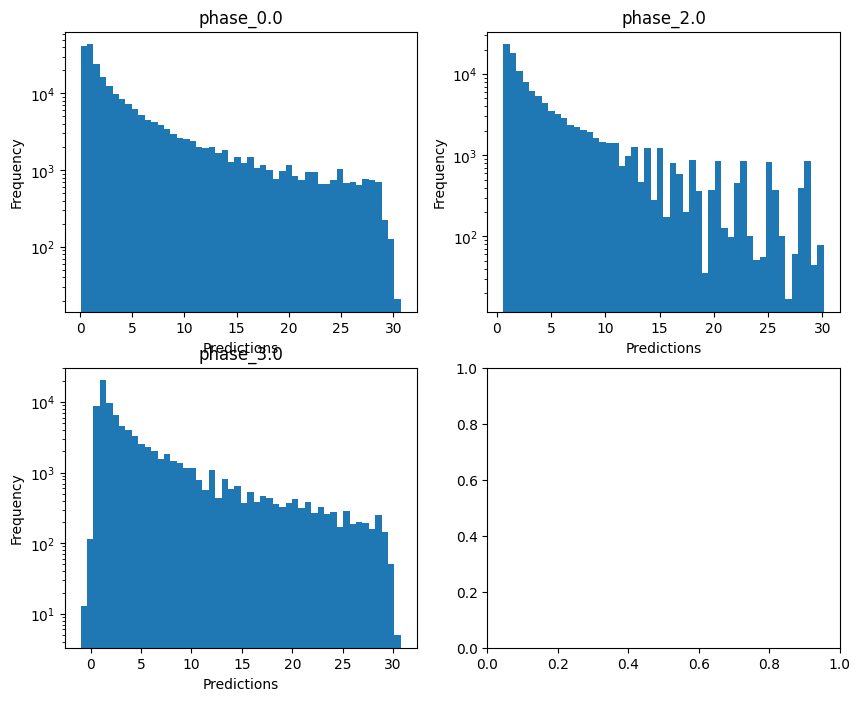

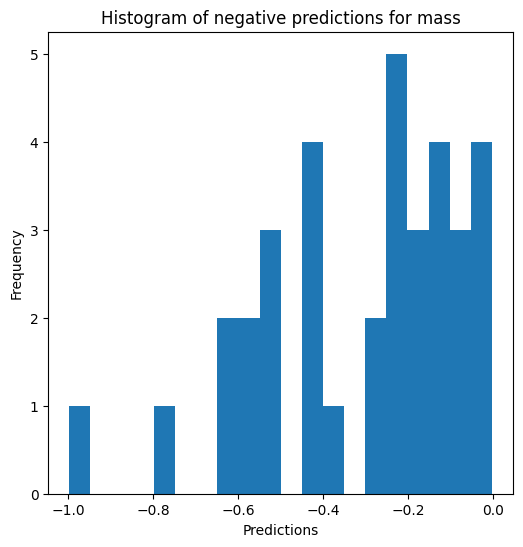


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.0827540579576227
  RVE :  0.9995444573828897
  RMSE :  0.010808218965673706
  MAE :  0.008221535385905357
  MedAE :  0.0064256563159944685
  CORR :  0.9997722073062707
  MAX_ER :  0.0721994507485072
  Percentiles : 
    75th percentile :  0.011512352239764018
    90th percentile :  0.0176832819881985
    95th percentile :  0.022129532046688046
    99th percentile :  0.031698646895197455

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.9992688621568159
  RMSE :  0.012340207213165378
  MAE :  0.009608870603818263
  MedAE :  0.007809194362370486
  CORR :  0.9996354916781848
  MAX_ER :  0.08310079986036634
  Percentiles : 
    75th percentile :  0.01363119604426423
    90th percentile :  0.02024537347905593
    95th percentile :  0.024765017072496866
    99th percentile :  0.03420552782258663

radius results for the

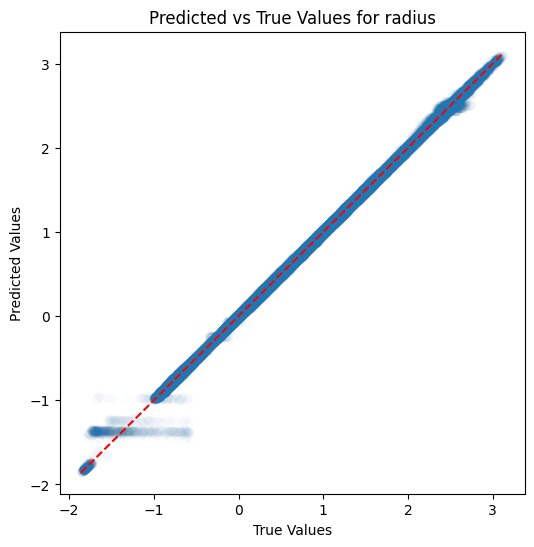

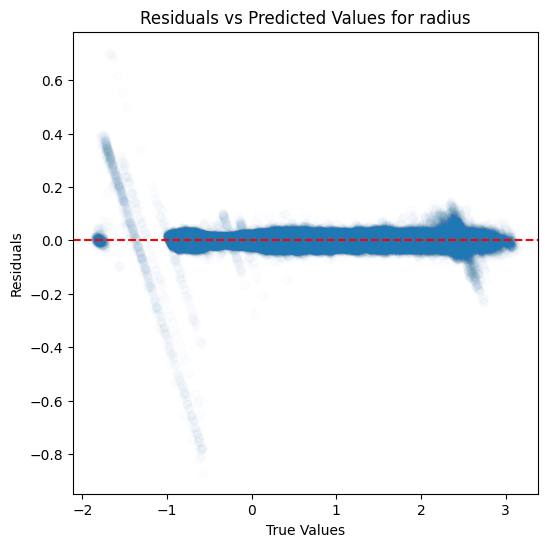

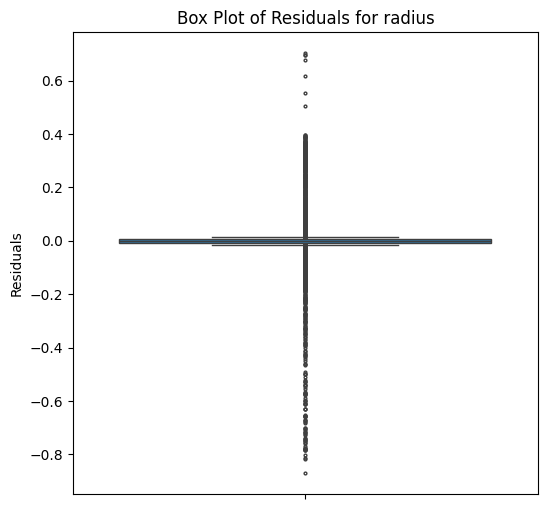

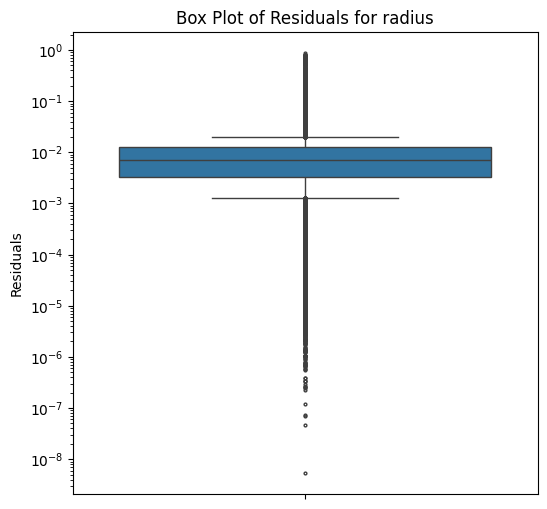

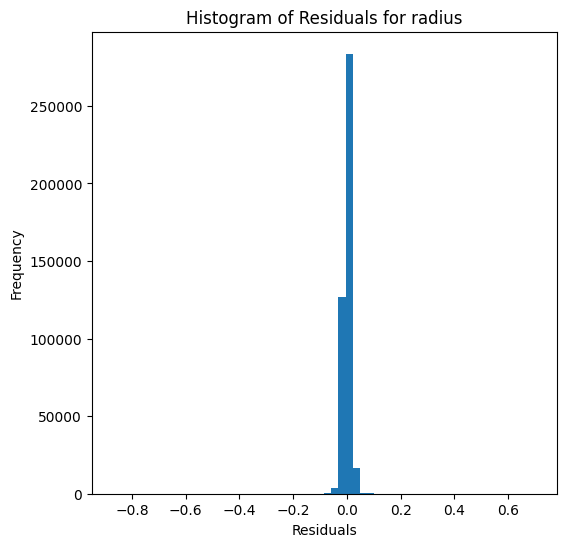

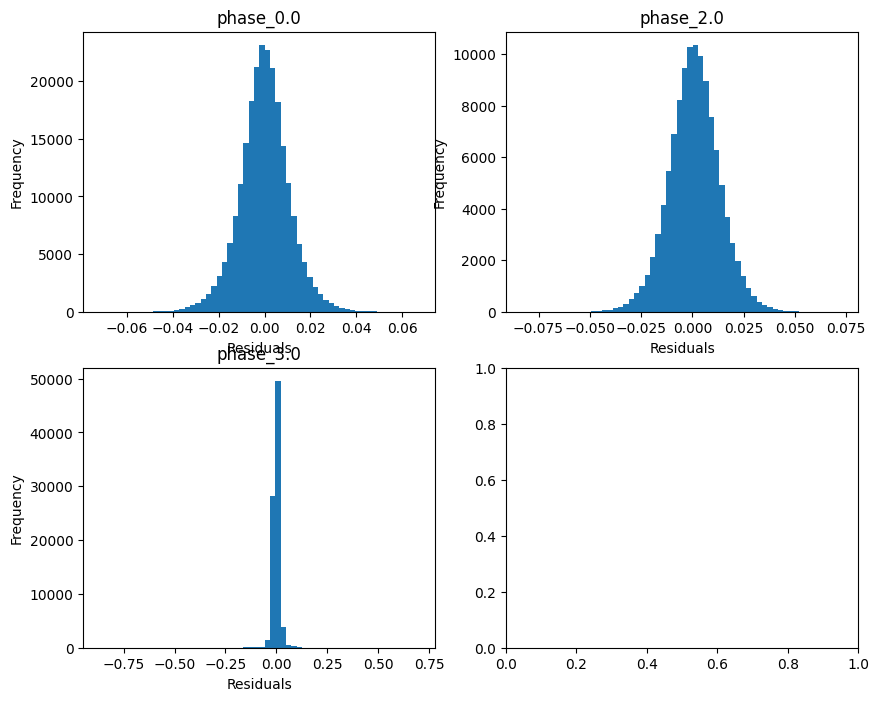

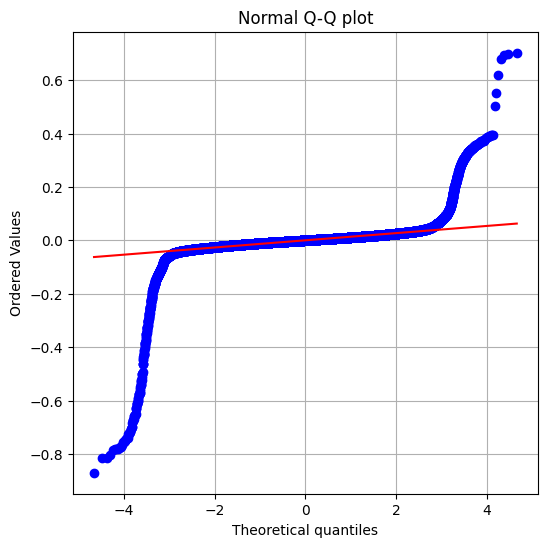

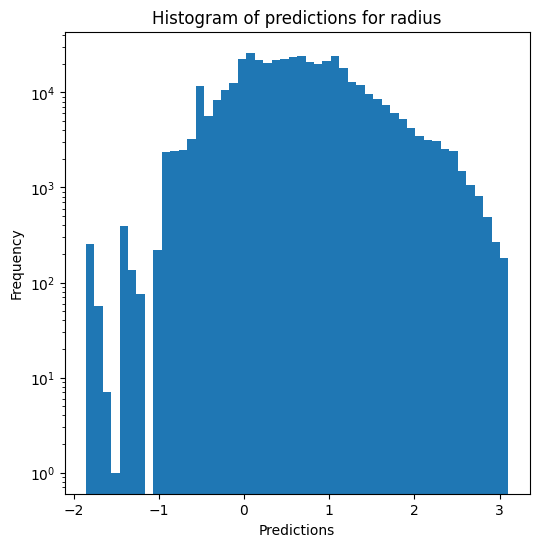

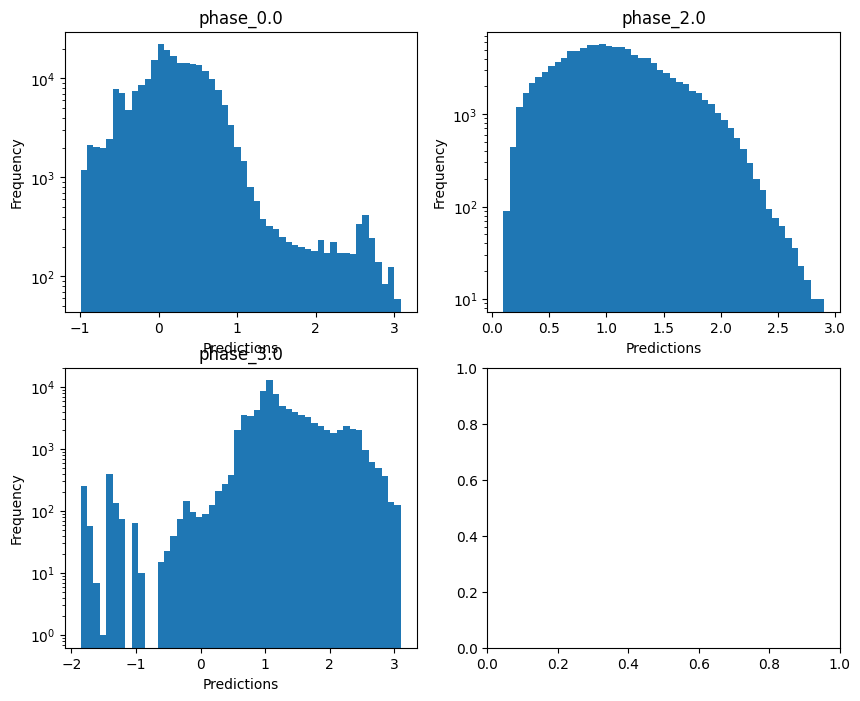

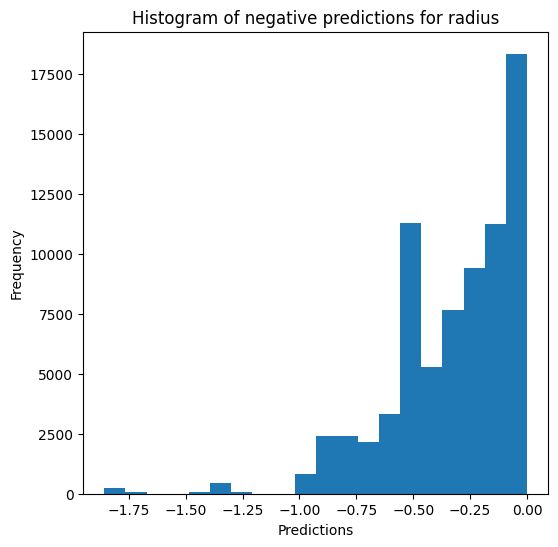

Saving predictions and results...


In [20]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=True, use_preds=False, save=True, show=True, n_jobs=5)

### Multi-layer perceptron

In [21]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_30 train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.10362945640804361
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.07841033106741502
3 

...

0.09791211746686733
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.11518997254445751
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.08396058335309585

Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.099998052173157 - 29.999136881366123
  RVE :  0.9892189263562553
  RMSE :  0.6553437928307626
  MAE :  0.24864924690696194
  MedAE :  0.10388373332624068
  CORR :  0.9946777408096366
  MAX_ER :  11.688757569553768
  Percentiles : 
    75th percentile :  0.19513094864479053
    90th percentile :  0.44854356121794
    95th percentile :  0.8835404401445964
    99th percentile :  3.433647734219938

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 29.67887151062485
  RVE :  0.9967538160059431
  RMSE :  0.35036012195355265
  MAE :  0.16982858627234326
  MedAE :  0.1144261130096238
  CORR :  0.9983803120639673
  MAX_ER :  10.488083669766144
  Percentiles : 
    75th percentile :  0.1887218341109188
    90th percentile :  0.3041167873595762
    95th percentile :  0.48391955036754025
    99th percentile :  1.134694904930363

mass

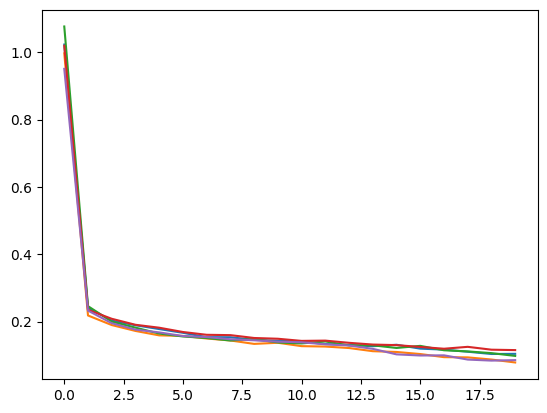

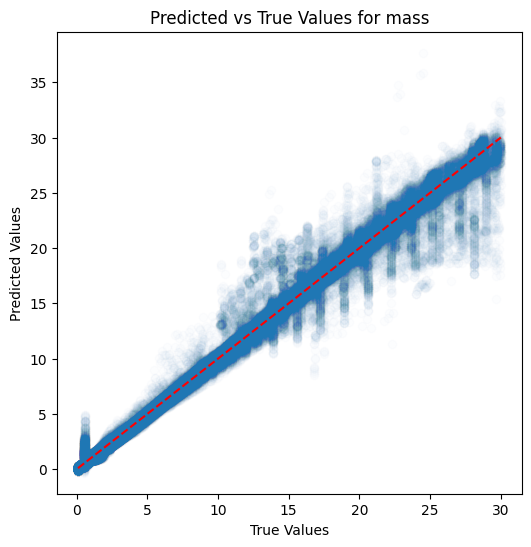

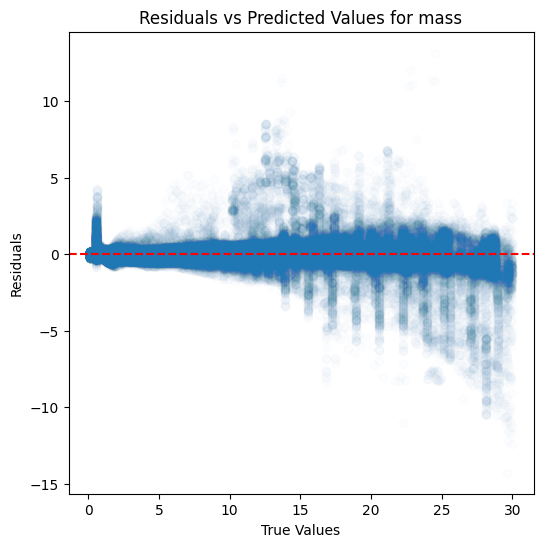

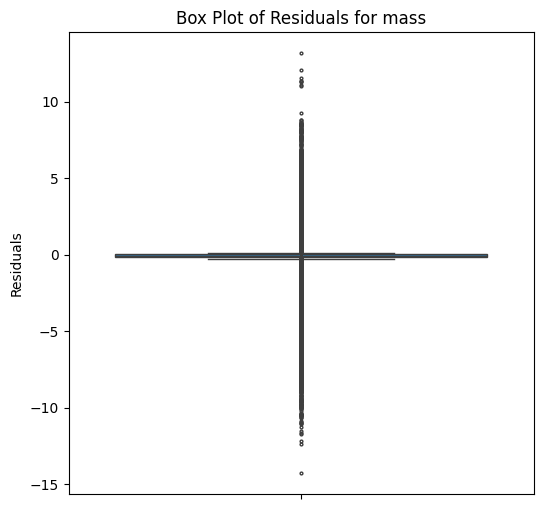

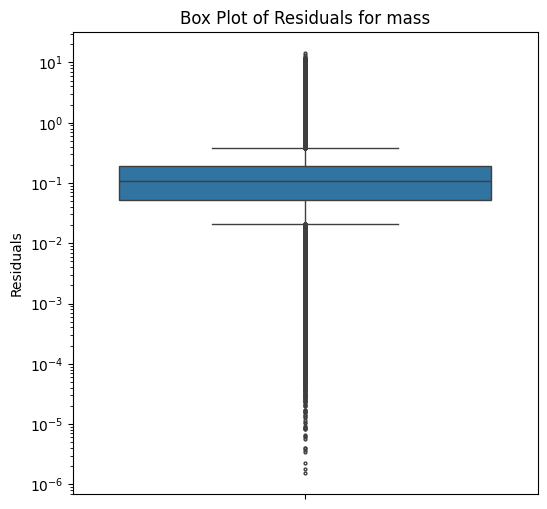

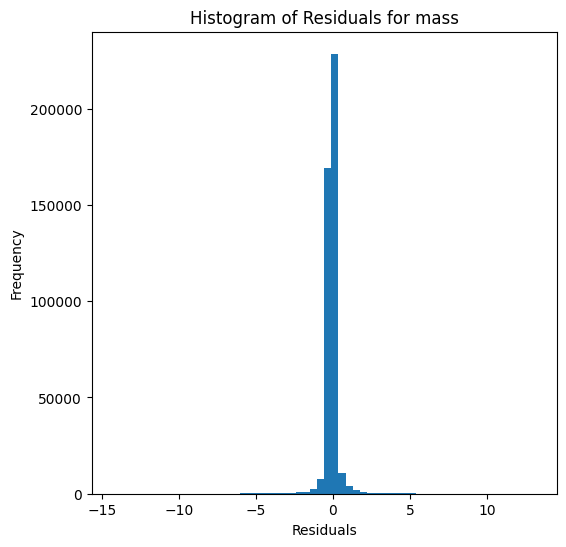

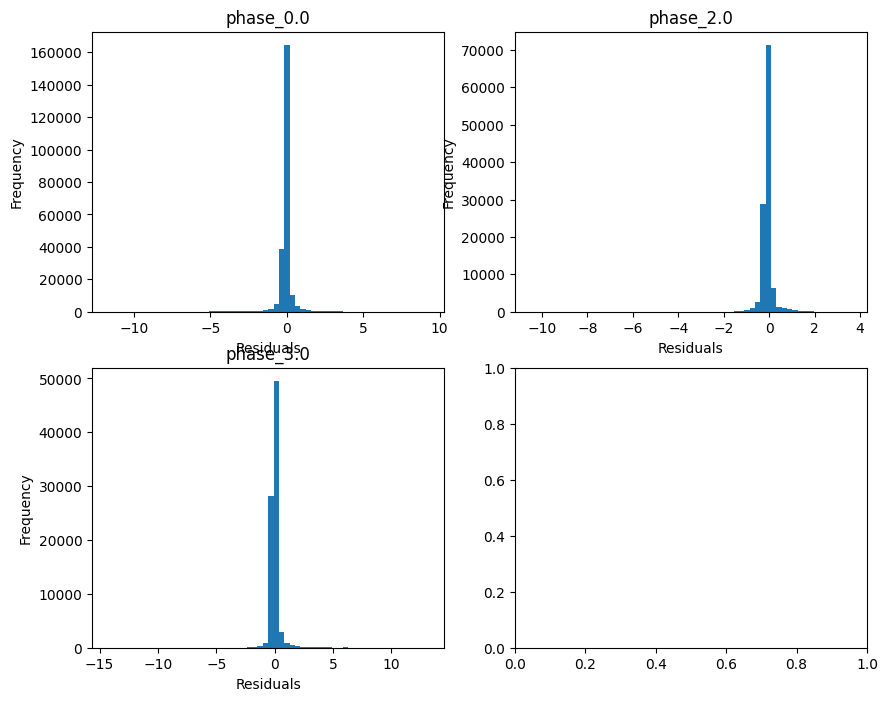

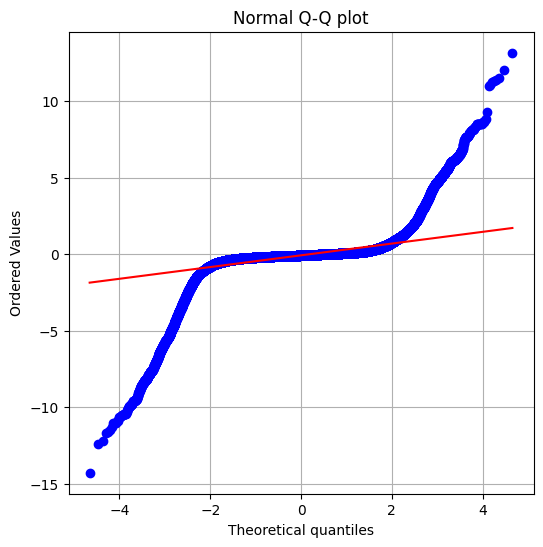

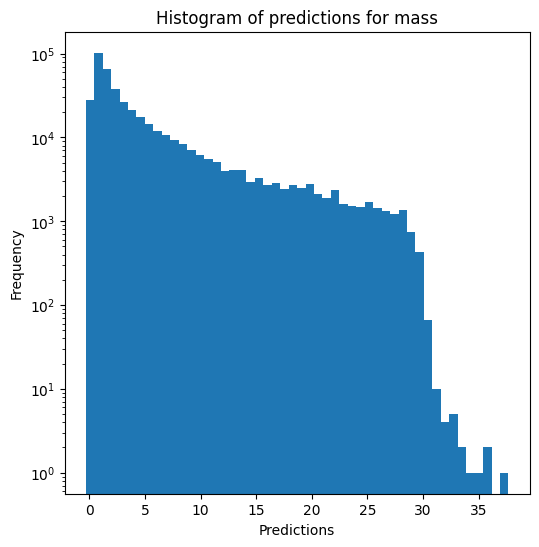

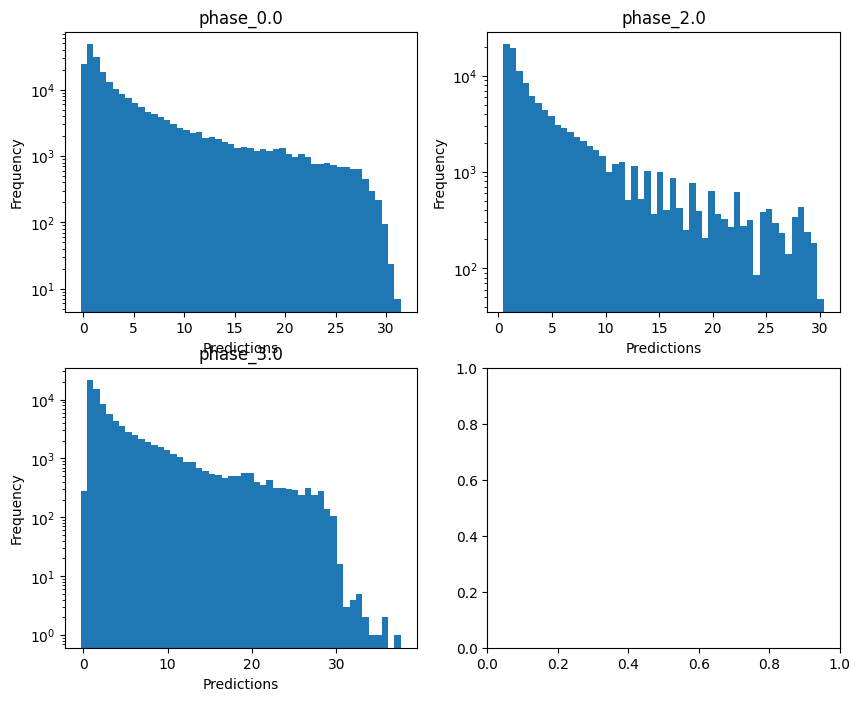

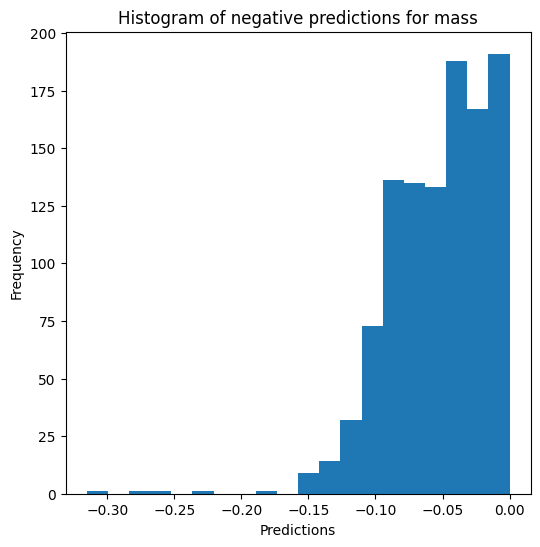


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.0827540579576227
  RVE :  0.9949918119955709
  RMSE :  0.03689426064665967
  MAE :  0.027875213300297234
  MedAE :  0.021436196371384435
  CORR :  0.9974943819239344
  MAX_ER :  0.2406016257426793
  Percentiles : 
    75th percentile :  0.03966168018960835
    90th percentile :  0.06006577167956579
    95th percentile :  0.0736865681999268
    99th percentile :  0.1063372991084356

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.900376516729969
  RVE :  0.993936749882818
  RMSE :  0.04036053124376285
  MAE :  0.031086217055393335
  MedAE :  0.024559976126819594
  CORR :  0.9969638655840041
  MAX_ER :  0.2723470444962355
  Percentiles : 
    75th percentile :  0.04407701238749079
    90th percentile :  0.06761959584922156
    95th percentile :  0.08141680049890569
    99th percentile :  0.11123561368834944

radius results for the phase cat

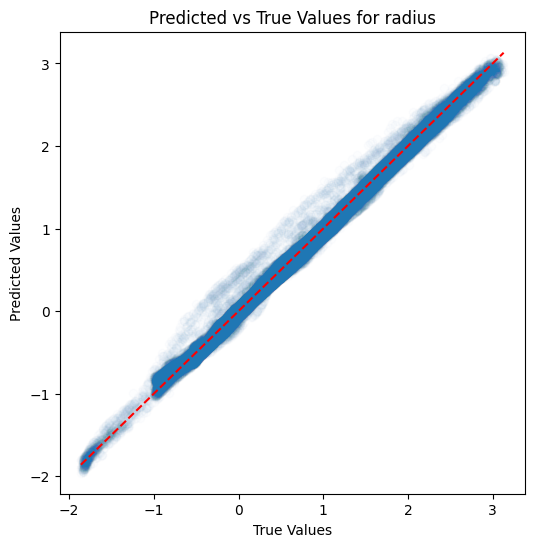

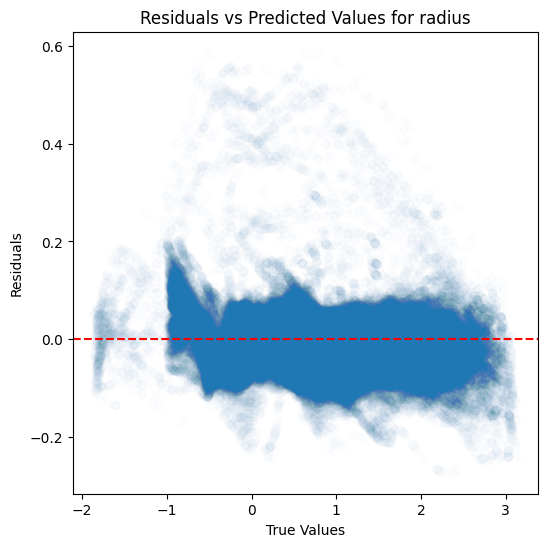

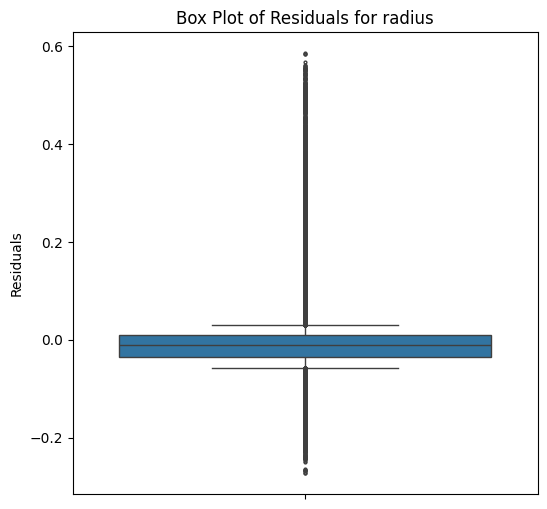

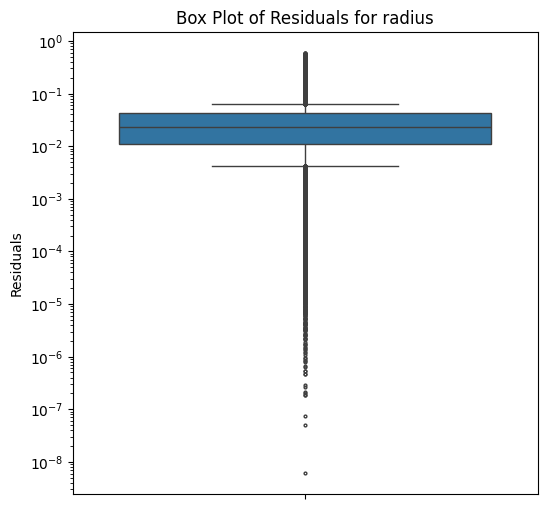

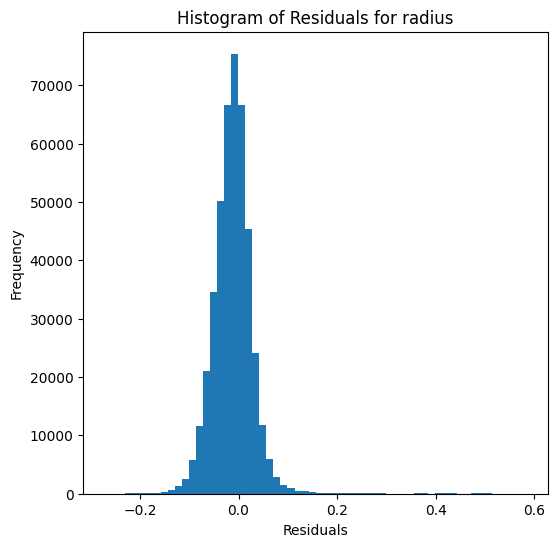

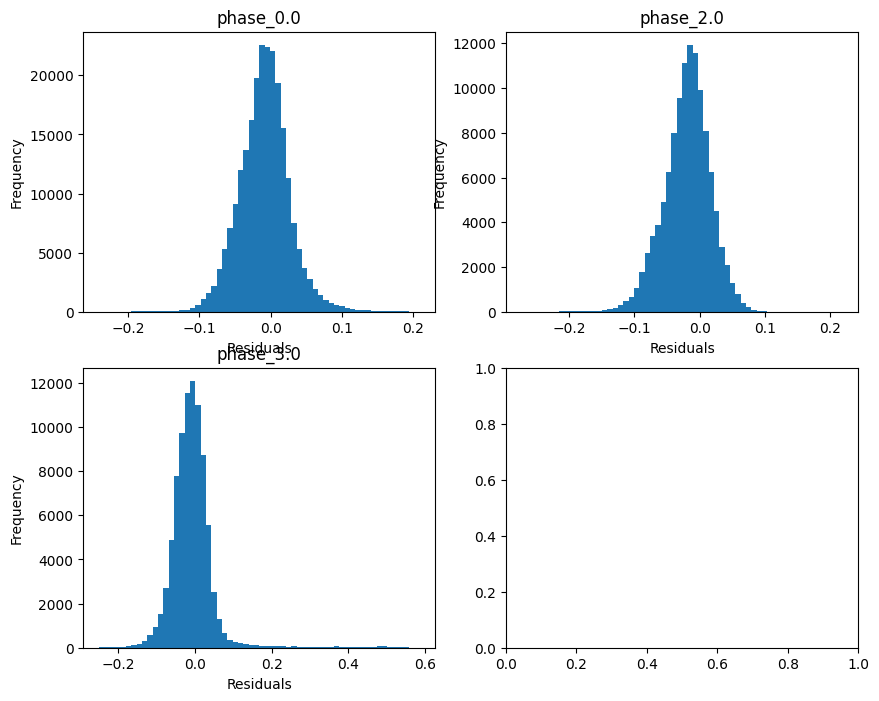

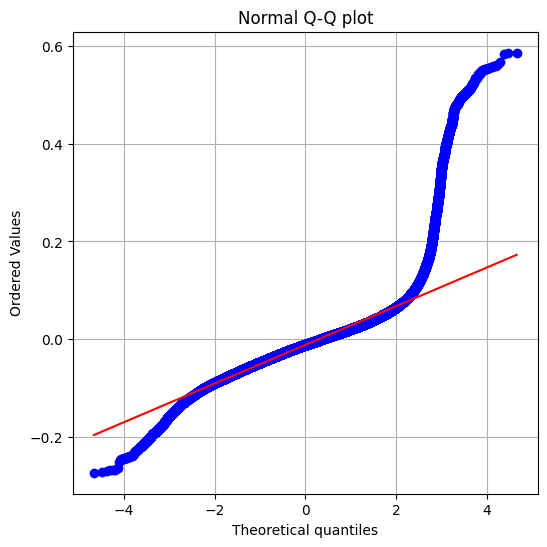

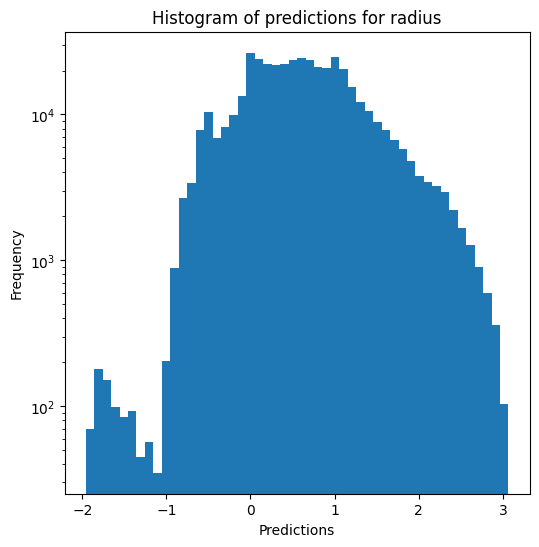

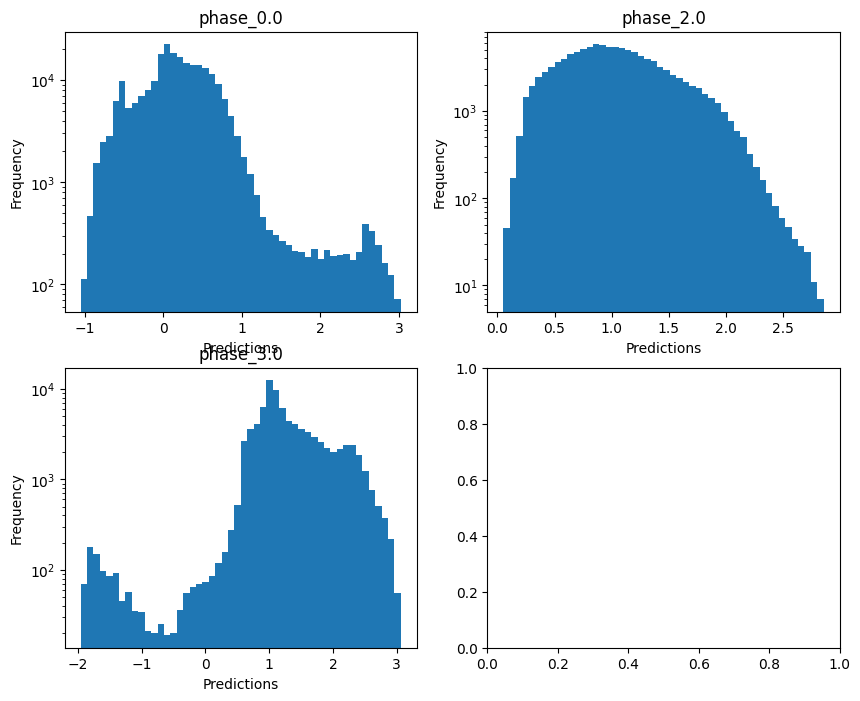

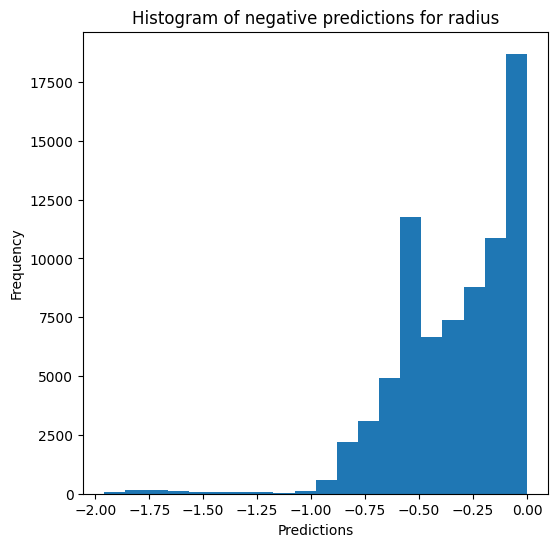

Saving predictions and results...


In [22]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=True, use_preds=False, save=True, show=True, 
                                     hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400) #, override=False, use_preds=True)